# Case 2 - High Season Decisions at Viador Hotels

**Data-Driven Decisions in Practice · D3 Applications · SS 2026**

Clara Schwarz oversees two mid-sized hotels under the Viador brand â€” a **city** location and a **resort** location. She wants your help refining pricing and capacity decisions for the upcoming high season. Your findings will brief her revenue and operations team: **clarity of communication is key**. Visualisations encouraged. *Pricing strategies should always rely on realised bookings, not mere requests.*

This template provides a **structural scaffold**. Every decision (segmentation thresholds, buffer levels, seasonal rules, adaptive policy) is yours to make and defend.

## §0 · Setup & data loader

The loader below is the same one used in the three companion notebooks. It downloads the public mirror of the Viador booking dataset and adds two helper columns (`booking_date`, `adr_per_adult`).

In [1]:
import numpy as np
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset"
    "/refs/heads/master/datasets/hotel_bookings.csv"
)


def load_bookings():
    df = pd.read_csv(DATA_URL)
    df["arrival_date"] = pd.to_datetime(
        df["arrival_date_year"].astype(str)
        + "-"
        + df["arrival_date_month"]
        + "-"
        + df["arrival_date_day_of_month"].astype(str),
        format="%Y-%B-%d",
        errors="coerce",
    )
    df["booking_date"] = df["arrival_date"] - pd.to_timedelta(
        df["lead_time"], unit="D"
    )
    df["adr_per_adult"] = df["adr"] / df["adults"].clip(lower=1)
    return df


bookings = load_bookings()
bookings.shape, bookings["arrival_date"].min(), bookings["arrival_date"].max()

((119390, 35),
 Timestamp('2015-07-01 00:00:00'),
 Timestamp('2017-08-31 00:00:00'))

In [2]:
#shared imports
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    recall_score,
    matthews_corrcoef,
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score


## §Q1 · Calibrate Advance Sale Policies

Clara offers discounted advance rates but only up to a certain number of bookings. Selling too many in advance turns away spontaneous, higher-paying guests; selling too few leaves occupancy short.

- Using **realised stays**, identify meaningful guest segments for each hotel. *When* do different guest types book? *What* prices do they pay?
- Estimate how many rooms Clara could allocate to advance sales **for each property**. Focus on lead times and, if useful, guest mix.

### Prevention of Data Distortion: Realized Stays Only

Analysing the commercial mix of both hotels requires focusing on realised bookings only. Including cancellations would overestimate true segment demand and distort price comparisons, since cancelled rates were never actually paid.

In [3]:
#realised bookings only df

realised = bookings[bookings["is_canceled"] == 0]
realised.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date,adr_per_adult
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,01-07-15,2015-07-01,2014-07-24,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,01-07-15,2015-07-01,2013-06-24,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,02-07-15,2015-07-01,2015-06-24,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,02-07-15,2015-07-01,2015-06-18,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,03-07-15,2015-07-01,2015-06-17,49.0


#### Lead Time Effects on Cancellation Rates

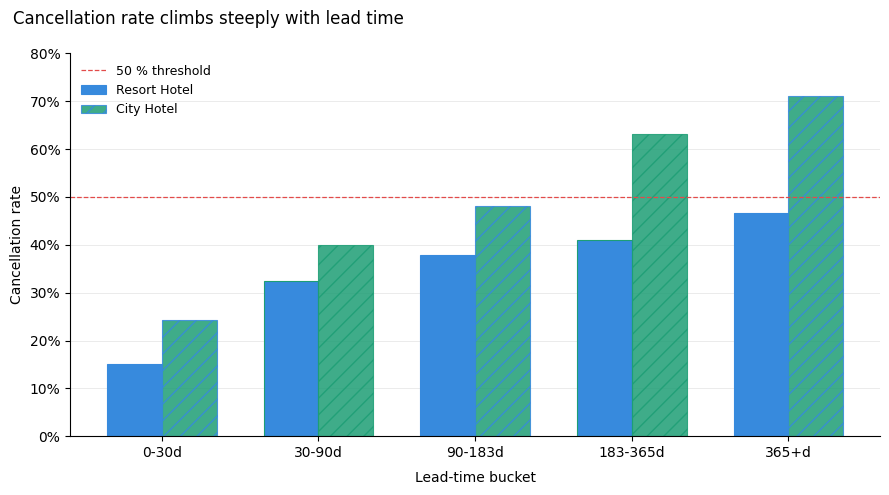

In [4]:
bookings["lead_bucket"] = (
    pd.cut(bookings["lead_time"],    #pd.cut() teilt kontinuierliche daten in bins ein
    [0, 30, 90, 183, 365, np.inf])  #list an buckets
)
canc_book = bookings.groupby(["hotel", "lead_bucket"], observed=True)["is_canceled"].mean() #pro bucket für jedes hotel durchschnitt an cancellations (=anteil, weil binär)

#bar plot
hotels = ["Resort Hotel", "City Hotel"]
buckets_canc = canc_book.index.get_level_values("lead_bucket").unique()
buckets_canc_labels = ["0-30d", "30-90d", "90-183d", "183-365d", "365+d"]

#layout
fig, ax = plt.subplots(figsize=(9, 5))
n_hotels = len(hotels)
x_ax = np.arange(len(buckets_canc)) #array mit fortlaufenden indizes für anzahl buckets
width_canc = 0.35
colors = ["#378ADD", "#1D9E75"]
hatches = [None, "//"]  

for i, ((hotel, color, hatch)) in enumerate(zip(hotels, colors, hatches)):      #zip(): macht tupel aus 1.:1. objekt, 2.:2. objekt usw.; enumerate(): gibt fortlaufende nummer pro tupel
    rates = [canc_book.loc[(hotel, b)] for b in buckets_canc] #für jeden bucket: schaut im cancelled grouped objekt nach der Kombination an (hotel, bucket) und holt den Anteil
    ax.bar(
        x_ax + (i - (n_hotels - 1)/2) * width_canc, #position der bars berechnen: über grundposition, breite der einzelnen bars und index (welches i-te hotel)
        rates,
        width_canc,
        label = hotel,
        color = color,
        alpha = 0.85 if hatch else 1.0,
        hatch = hatch,
        edgecolor = colors,
        linewidth = 0.8,
    )

ax.axhline(0.5, color="#E24B4A", linewidth=0.9, linestyle="--", label="50 % threshold")

ax.set_xticks(x_ax)
ax.set_xticklabels(buckets_canc_labels)
ax.set_xlabel("Lead-time bucket", labelpad=8)
ax.set_ylabel("Cancellation rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.80)
ax.yaxis.grid(True, linewidth=0.4, color="gainsboro")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(frameon=False, fontsize=9)
fig.suptitle(
    "Cancellation rate climbs steeply with lead time",
    x=0.02, ha="left", fontsize=12, fontweight="medium",
)

plt.tight_layout()
plt.show()

Clara's pricing decisions should reflect what guests actually paid, not what they intended to pay. Since cancellation rates vary systematically with lead time, including cancelled bookings would distort both segment volumes and price comparisons. All subsequent analysis is therefore restricted to realised stays.

### Controlling for Composition Effects: Canonical homogenisation

Before analysing guest segments, we need to decide how to define them. We use booking lead time as the segmentation criterion, since early and late bookers tend to represent structurally different guest types with different price sensitivities. However, room type, meal plan, and party size may also influence ADR independently. If their mix differs systematically between early and late bookers, any timing gap we measure would be partly a composition effect rather than a genuine pricing signal.


To assess how much each dimension actually moves ADR, we plot ADR distributions by room type, meal plan, and party size separately for each hotel. If the spread across categories is large, that dimension needs to be held fixed before any early/late comparison is meaningful.

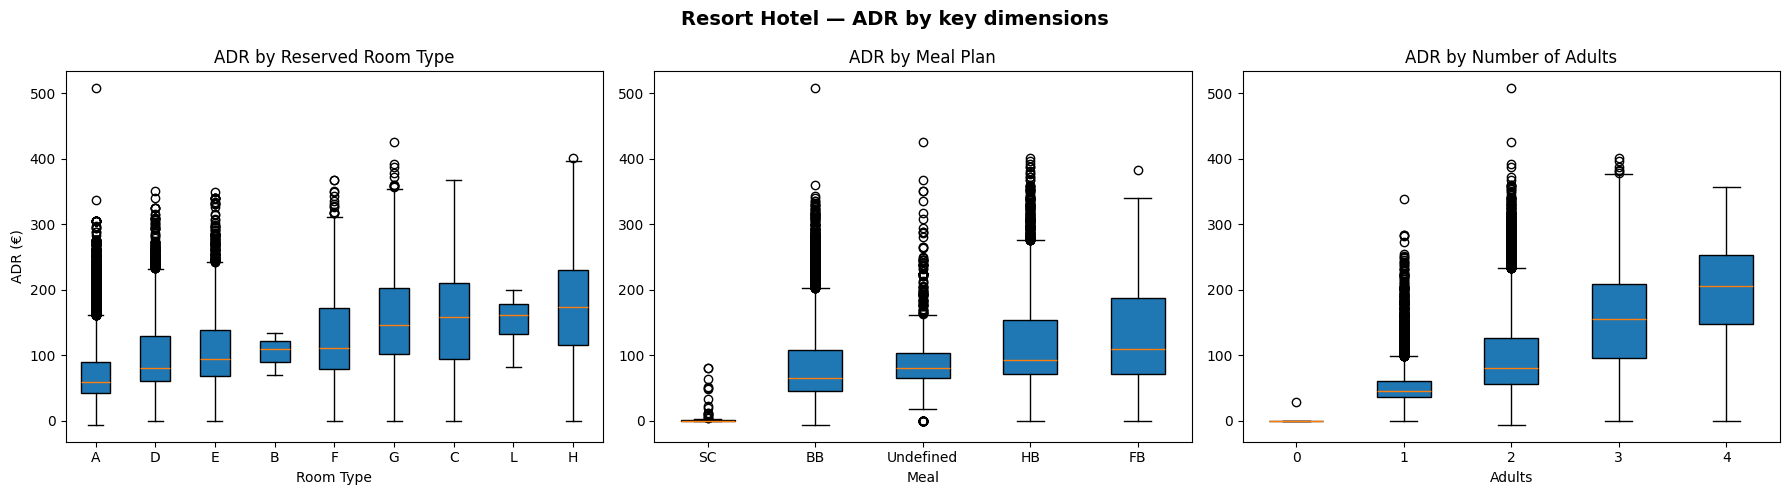

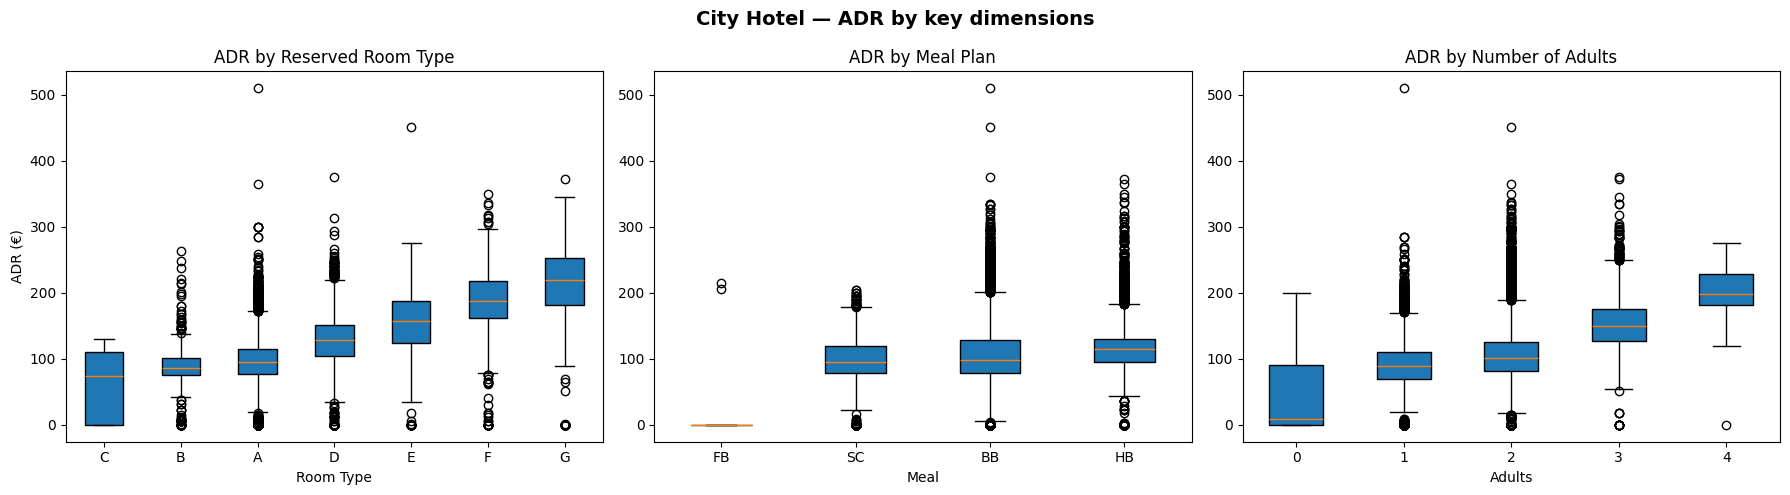

Median ADR by room type (€)


,Resort Hotel,City Hotel
reserved_room_type,,
A,58.98,94.50
B,110.00,86.50
C,158.67,74.00
D,80.00,129.18
E,93.67,157.98
F,111.46,187.85
G,146.61,219.46
H,174.00,NaN
L,161.00,NaN


Median ADR by meal plan (€)


,Resort Hotel,City Hotel
meal,,
BB,65.42,99.0
FB,110.00,0.0
HB,93.00,114.4
SC,0.00,95.1
Undefined,80.00,NaN


Median ADR by number of adults (€)


,Resort Hotel,City Hotel
adults,,
0,0.00,8.34
1,45.00,89.00
2,80.00,101.00
3,155.00,150.30
4,205.33,198.54


Spread per dimension (€)


,Room Type,Meal Plan,Adults
Hotel,,,
Resort Hotel,115.02,110.0,205.33
City Hotel,145.46,114.4,190.20


In [5]:
#plots
median_tables = {"reserved_room_type": {}, "meal": {}, "adults": {}}
spread_rows = []

for hotel in hotels:
    df = realised[realised["hotel"] == hotel] #durch beide hotels loopen

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{hotel} — ADR by key dimensions", fontsize=14, fontweight="bold")

    #room type
    order_room = df.groupby("reserved_room_type")["adr"].median().sort_values().index   #nach room groupen und medain pro roomtype, nach median ordnen; .index holt nur sortierte room_types
    groups_room = [df[df["reserved_room_type"] == r]["adr"] for r in order_room] #für jeden room type liste aller preise
    axes[0].boxplot(groups_room, tick_labels=order_room, patch_artist=True)
    axes[0].set_title("ADR by Reserved Room Type")
    axes[0].set_xlabel("Room Type")
    axes[0].set_ylabel("ADR (€)")

    #meal code logik identisch
    order_meal = df.groupby("meal")["adr"].median().sort_values().index
    groups_meal = [df[df["meal"] == m]["adr"] for m in order_meal]
    axes[1].boxplot(groups_meal, tick_labels=order_meal, patch_artist=True)
    axes[1].set_title("ADR by Meal Plan")
    axes[1].set_xlabel("Meal")

    #adults
    order_adults = sorted(df["adults"].unique())    #alle möglichkeiten an anzahl, sortiert
    groups_adults = [df[df["adults"] == a]["adr"] for a in order_adults]
    axes[2].boxplot(groups_adults, tick_labels=[str(int(a)) for a in order_adults], patch_artist=True)
    axes[2].set_title("ADR by Number of Adults")
    axes[2].set_xlabel("Adults")

    plt.tight_layout()
    plt.show()

    #quantifizierung sammeln
    for dim in ["reserved_room_type", "meal", "adults"]:
        med = df.groupby(dim)["adr"].median()
        median_tables[dim][hotel] = med

    spread_rows.append({
        "Hotel": hotel,
        "Room Type": median_tables["reserved_room_type"][hotel].max() - median_tables["reserved_room_type"][hotel].min(),
        "Meal Plan": median_tables["meal"][hotel].max() - median_tables["meal"][hotel].min(),
        "Adults": median_tables["adults"][hotel].max() - median_tables["adults"][hotel].min(),
    })

#erst nach dem loop: alle tabellen
print("Median ADR by room type (€)")
display(pd.DataFrame(median_tables["reserved_room_type"]).round(2))

print("Median ADR by meal plan (€)")
display(pd.DataFrame(median_tables["meal"]).round(2))

print("Median ADR by number of adults (€)")
display(pd.DataFrame(median_tables["adults"]).round(2))

print("Spread per dimension (€)")
display(pd.DataFrame(spread_rows).set_index("Hotel").round(2))

The boxplots and spread calculations show that each of the three dimensions individually shifts median ADR by €110 to €205, an amount large enough to manufacture or erase any timing effect entirely. If room type, meal plan, or party size are left free, a difference in booking mix between early and late guests would contaminate the gap we measure, making it impossible to attribute to pricing rather than composition. We therefore fix all three jointly before running any customer segment comparison.

However, fixing a tuple is only meaningful if it reflects how guests actually book. A canonical choice that covers a negligible share of realised stays produces unstable medians and an unrepresentative baseline. We therefore identify the modal (room, meal, adults) combination per hotel by frequency:

The tuple that is both the most common realised booking and carries enough volume to yield reliable estimates on both sides of any lead-time cut.

In [6]:
combo = (
    realised.groupby(["hotel", "reserved_room_type", "meal", "adults"]) #nach tupel gruppieren für jedes hotel
    .size()     #anzahl zählen
    .reset_index(name="n")  
    .sort_values(["hotel", "n"], ascending=[True, False])   #sortieren: zuerst nach hotel, dann der häufigkeit nach
)

hotel_totals = realised.groupby("hotel").size().rename("hotel_total")   #bookings pro hotel
combo = combo.join(hotel_totals, on="hotel")        #zusammenführen
combo["share_pct"] = (combo["n"] / combo["hotel_total"] * 100).round(2) #anteil spalte

print("Top 5 tuples per hotel:\n")
for hotel, grp in combo.groupby("hotel"):       #grp ist df mit nur einträgen des hotels
    top5 = grp.head(5).reset_index(drop=True)   #combo schon sortier, also einfach obersten 5 holen
    cumulative = top5["share_pct"].sum()        #anteile der top 5 summieren für kumulativen anteil
    print(f"Hotel: {hotel}  (total realised bookings: {grp['hotel_total'].iloc[0]:,})")
    print(top5[["reserved_room_type", "meal", "adults", "n", "share_pct"]].to_string(index=False))
    print(f"Top-5 tuples cover {cumulative:.1f}% of this hotel's realised bookings\n")

Top 5 tuples per hotel:

Hotel: City Hotel  (total realised bookings: 46,228)
reserved_room_type meal  adults     n  share_pct
                 A   BB       2 17506      37.87
                 A   BB       1  7436      16.09
                 A   SC       2  5291      11.45
                 D   BB       2  4440       9.60
                 A   HB       2  2578       5.58
Top-5 tuples cover 80.6% of this hotel's realised bookings

Hotel: Resort Hotel  (total realised bookings: 28,938)
reserved_room_type meal  adults    n  share_pct
                 A   BB       2 8600      29.72
                 A   BB       1 4304      14.87
                 D   BB       2 3655      12.63
                 E   BB       2 2380       8.22
                 A   HB       2 2210       7.64
Top-5 tuples cover 73.1% of this hotel's realised bookings



The most representative booking type for both hotels is A/BB/2 by a considerable margin, so we fix it as the shared canonical tuple for all subsequent analysis. Coverage is strongly concentrated. The top five tuples account for 80.6% of City Hotel and 73.1% of Resort Hotel realised bookings, with a steep drop in frequency after the modal entry. A single canonical tuple as the basis for further modelling is therefore well justified.

We further restrict the analysis to realised bookings with an ADR between €0 and €250 and a lead time of at most 365 days. A nightly rate above €250 or a booking horizon beyond one year falls outside the plausible operating range of a typical city or resort hotel, so observations outside these bounds are treated as data artefacts that would distort distributional summaries without reflecting genuine pricing behaviour.

Fixing the canonical tuple removes the compositional bias from room type, meal plan, and party size, but a second confounder remains. Seasonality. If early and late bookers systematically arrive in different months, any ADR gap we measure would partly reflect the seasonal price level, not the timing of the booking decision. To isolate a clean lead-time effect, we therefore identify the months where ADR is structurally elevated and restrict the early/late comparison to those months. We first inspect the demand calendar, both arrival volume and canonical ADR, over the full 2015 to 2017 timeline to determine which months constitute the economically relevant high season.

### Identification of Seasonal Peak Demand

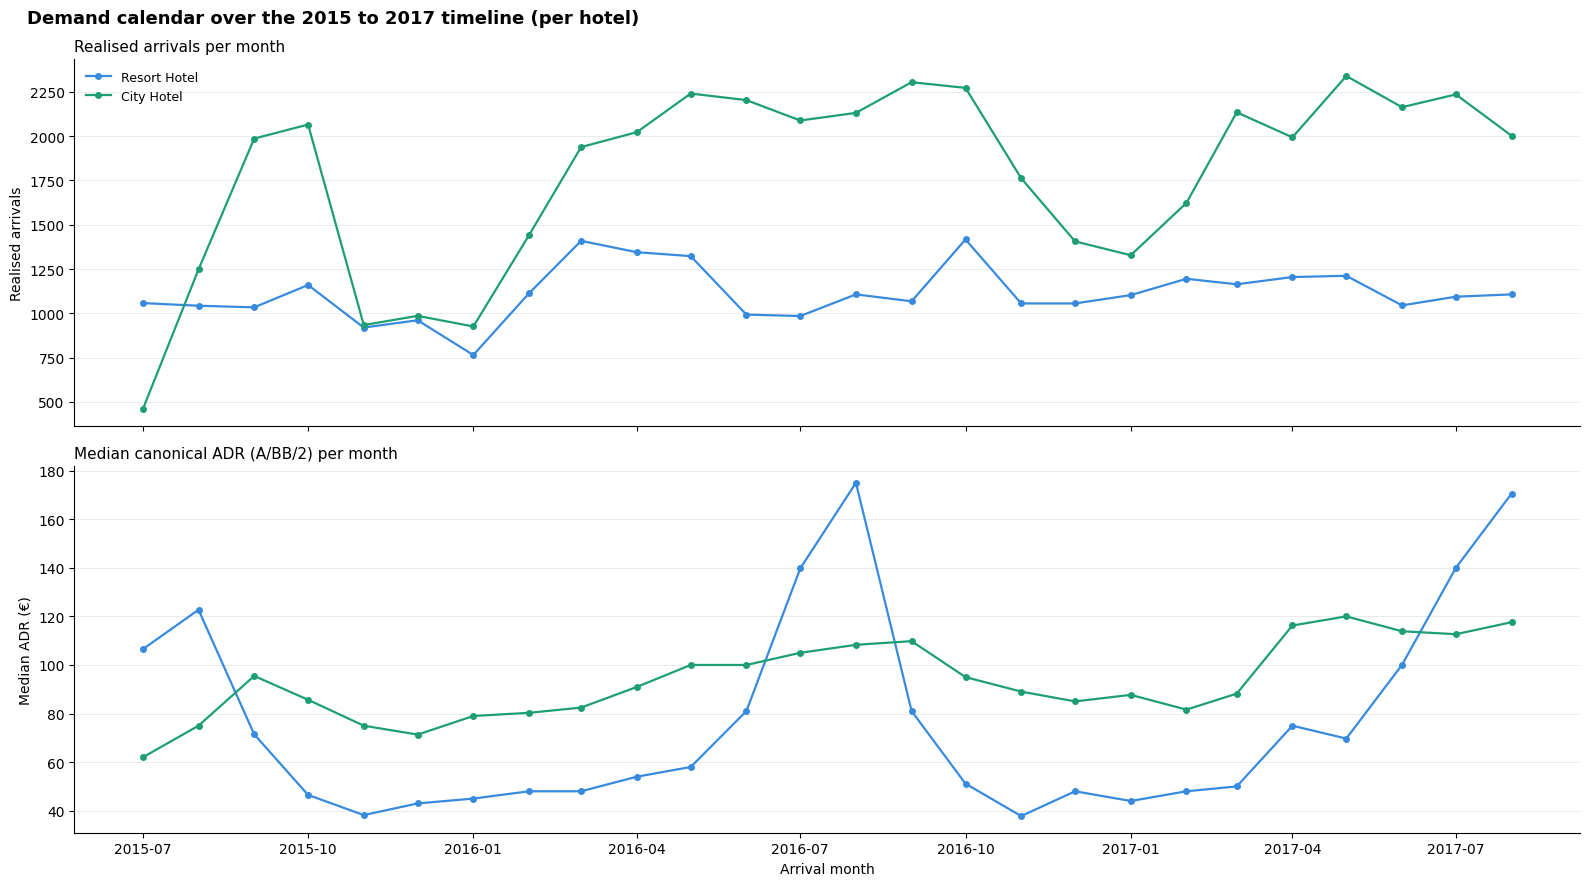

arrival_date_month,April,August,December,February,January,July,June,March,May,November,October,September
hotel,,,,,,,,,,,,
City Hotel,1549,2089,997,1064,717,1609,1553,1649,1720,1036,1804,1719
Resort Hotel,573,922,504,707,601,944,618,703,804,613,969,642


In [7]:
# arrival time series_ realised arrivals per month over entire timeline 

hotel_colors = dict(zip(hotels, colors))    #listen von oben verwenden

#canonical parameters

rooms = "A"
meals = "BB"
adults = 2

realised = realised.copy()
realised["arrival_ym"] = realised["arrival_date"].dt.to_period("M").dt.to_timestamp()   #ym spalte: zur vorbereitung für aggregation

canon = realised[
    (realised["reserved_room_type"] == rooms)
    & (realised["meal"] == meals)
    & (realised["adults"] == adults)
]

arrivals_ts = (
    realised.groupby(["arrival_ym", "hotel"])   #nach monat und hotel groupen
    .size()                                     #arrivals pro monat zählen
    .reset_index(name="value")
)

adr_ts = (
    canon.groupby(["arrival_ym", "hotel"])["adr"]   #selbe logik nur median
    .median()
    .reset_index(name="value")
)


monthly_time_series = (
    realised.groupby(["arrival_ym", "hotel"]) 
    .size()                                     
    .reset_index(name="n_arrivals")
)

#kleine helper function damit wir nicht zwei loops machen müssen:

fig, (ax_arr, ax_adr) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

def draw(ax, data, ylabel):
    for hotel, color in hotel_colors.items():
        s = data[data["hotel"] == hotel].sort_values("arrival_ym")
        ax.plot(s["arrival_ym"], s["value"], marker="o", markersize=4,
                linewidth=1.6, color=color, label=hotel)
    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linewidth=0.4, color="gainsboro")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

draw(ax_arr, arrivals_ts, "Realised arrivals")
draw(ax_adr, adr_ts, "Median ADR (€)")

# titel pro subplot, x-label nur unten (wegen sharex)
ax_arr.set_title("Realised arrivals per month", loc="left", fontsize=11)
ax_adr.set_title("Median canonical ADR (A/BB/2) per month", loc="left", fontsize=11)
ax_adr.set_xlabel("Arrival month")
ax_arr.legend(frameon=False, fontsize=9)   # legende nur einmal nötig

fig.suptitle("Demand calendar over the 2015 to 2017 timeline (per hotel)",
             x=0.02, ha="left", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()
canon.groupby(["hotel", "arrival_date_month"]).size().unstack()
monthly_counts = canon.groupby(["hotel", "arrival_date_month"]).size().unstack()
display(monthly_counts)

The two time series reveal structurally different demand calendars across the two hotels. City Hotel shows a relatively flat ADR profile year-round, with a mild elevation in spring and early summer and a slight dip in winter. Resort Hotel differs sharply. Its ADR collapses to €40 to €50 in winter and spikes to €175 in August. The pattern repeats across the summers in the data, which confirms it is structural rather than noise.

Notably, Resort Hotel's volume and price signals point in opposite directions. Winter, spring and autumn generate the highest arrival counts, while summer generates the highest ADR. A volume-based definition of high season would therefore misidentify the economically relevant peak.

We define high season by ADR elevation, meaning the period during which a hotel has enough pricing power for early/late fare differentiation to be meaningful. Pooling all months would introduce the seasonal price level as an additional driver, making it impossible to attribute any ADR gap purely to booking timing.

On this basis we apply the same criterion to both hotels. We restrict the early/late analysis to the period where seasonality could otherwise distort the timing gap. For Resort Hotel, the pronounced summer peak makes this restriction necessary, so we define its high season as June to August and limit the analysis to arrivals in those months. For City Hotel, the ADR profile is flat enough year-round that seasonality is not a meaningful confounder, so no seasonal restriction is needed and we retain the full timeline.

Volume supports both choices. For the canonical tuple A/BB/2, Resort yields 618, 922 and 944 realised bookings across June, July and August, while City retains its full-year sample. This is well above what is needed for stable median estimates on both sides of any lead-time cut.

### Quantifying ADR Gaps Across Lead Time Windows

In [8]:
#helper um das plotten und cut auswahl einfacher zu machen

cut_range = range(1, 366)

def canon_subset(hotel, months=None):
    df = canon[canon["hotel"] == hotel]
    if months is not None:
        df = df[df["arrival_date"].dt.month.isin(months)]
    return df

def gap_sweep(df, cut_range=cut_range, min_n=1):            #Pro cut: early/late teilen, gap und IQR festhalten
    cols = ["cut", "n_early", "n_late", "med_early", "med_late",
            "gap", "iqr_early", "iqr_late", "pooled_iqr"]
    rows = []
    for cut in cut_range:
        early = df.loc[df["lead_time"] >= cut, "adr"]
        late  = df.loc[df["lead_time"] <  cut, "adr"]
        if len(early) < min_n or len(late) < min_n:
            continue
        iqr_e = early.quantile(.75) - early.quantile(.25)
        iqr_l = late.quantile(.75)  - late.quantile(.25)
        rows.append({
            "cut": cut,
            "n_early": len(early), "n_late": len(late),
            "med_early": early.median(), "med_late": late.median(),
            "gap": late.median() - early.median(),
            "iqr_early": iqr_e, "iqr_late": iqr_l,
            "pooled_iqr": (iqr_e + iqr_l) / 2,
        })
    return pd.DataFrame(rows, columns=cols)   # <-- Spalten immer da

To find a meaningful early/late boundary, we sweep a candidate lead-time cut from 1 to 365 days. At each cut, we split the realised canonical bookings into an early bucket and a late bucket and measure the gap between their median ADR. A gap that stays positive and stable across a wide range of cuts indicates that late bookers reliably pay more, which is the signal we need to size advance sales.

For Resort Hotel we run the sweep both on all months and on its high season, so we can see whether the timing gap survives once the seasonal price level is removed. For City Hotel, whose ADR profile is flat, no seasonal restriction is applied and the full year is used.

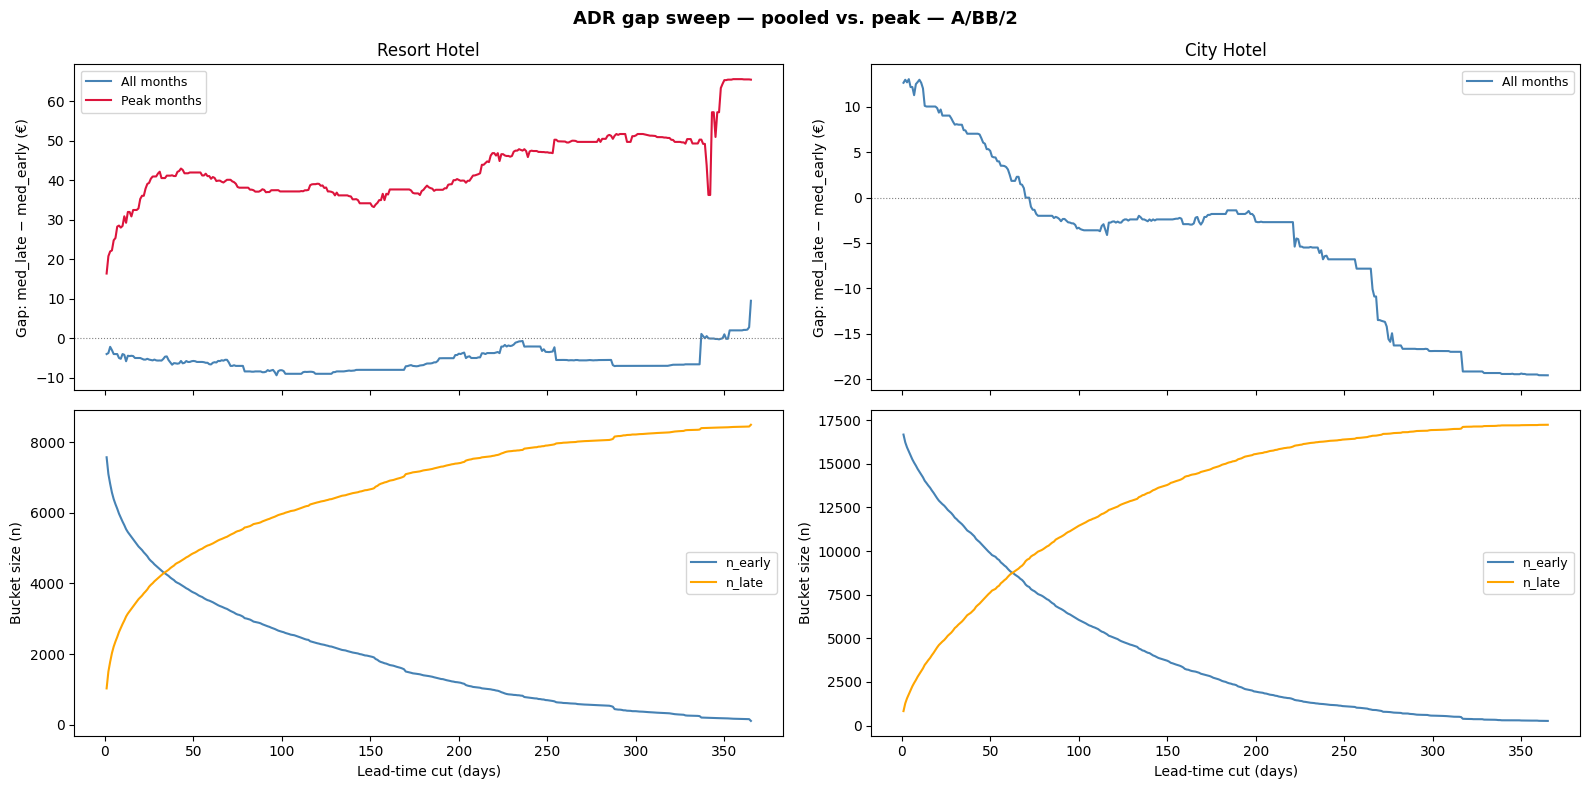

In [9]:
peak_months = {"Resort Hotel": [6, 7, 8]}   # City nutzt das ganze jahr, also keine peak-einschränkung

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex="col")
fig.suptitle(f"ADR gap sweep — pooled vs. peak — {rooms}/{meals}/{adults}",
             fontsize=13, fontweight="bold")

sweeps = {}

for col, hotel in enumerate(hotels):
    # pooled = alle monate: citys finale analyse, resorts baseline
    pooled = gap_sweep(canon_subset(hotel))
    sweeps[(hotel, "pooled")] = pooled

    axes[0, col].plot(pooled["cut"], pooled["gap"],
                      color="steelblue", linewidth=1.5, label="All months")
    axes[1, col].plot(pooled["cut"], pooled["n_early"], color="steelblue", label="n_early")
    axes[1, col].plot(pooled["cut"], pooled["n_late"],  color="orange",    label="n_late")

    # peak nur dort overlayen wo eine high season definiert ist (resort)
    if hotel in peak_months:
        peak = gap_sweep(canon_subset(hotel, peak_months[hotel]))
        sweeps[(hotel, "peak")] = peak
        axes[0, col].plot(peak["cut"], peak["gap"],
                          color="crimson", linewidth=1.5, label="Peak months")

    axes[0, col].axhline(0, color="grey", linestyle=":", linewidth=0.8)
    axes[0, col].set_title(hotel)
    axes[0, col].set_ylabel("Gap: med_late − med_early (€)")
    axes[0, col].legend(fontsize=9)

    axes[1, col].set_xlabel("Lead-time cut (days)")
    axes[1, col].set_ylabel("Bucket size (n)")
    axes[1, col].legend(fontsize=9)

plt.tight_layout()
plt.show()

The contrast between the two Resort curves show key results. Across all months, the gap sits near zero and is in fact slightly negative over most cuts, which on its own would suggest that early bookers pay no more than late ones. Restricting to the summer high season reverses this completely: the gap is positive across the entire range. Pooling does not merely dilute the timing effect, it masks and inverts it. Only within the high season, where the hotel holds genuine pricing power, does the true lead-time effect emerge. The seasonal restriction is therefore not optional for Resort.

City Hotel behaves differently. Its full-year gap is positive only at short cuts and turns negative beyond that. Late guests pay a premium only at short booking horizons, consistent with last-minute corporate demand, so any advance-sale boundary for City has to sit within that early window. The bucket-size panels confirm that both sides of the cut stay well populated across the relevant range for both hotels.

#### Heterogeneity Analysis Across Temporal Subperiods

The peak gap could in principle be produced by a single dominant slice of the season rather than by booking timing itself. We therefore re-run the sweep on subsets and overlay them on the combined curve. For Resort Hotel we split by individual peak month, for City Hotel by quarter. If the subset curves track the combined curve in shape and sign, the gap is a genuine lead-time effect rather than an artefact of mixing. A thin-bucket guard of at least 30 observations per side keeps unstable medians from sparse subsets out of the comparison.

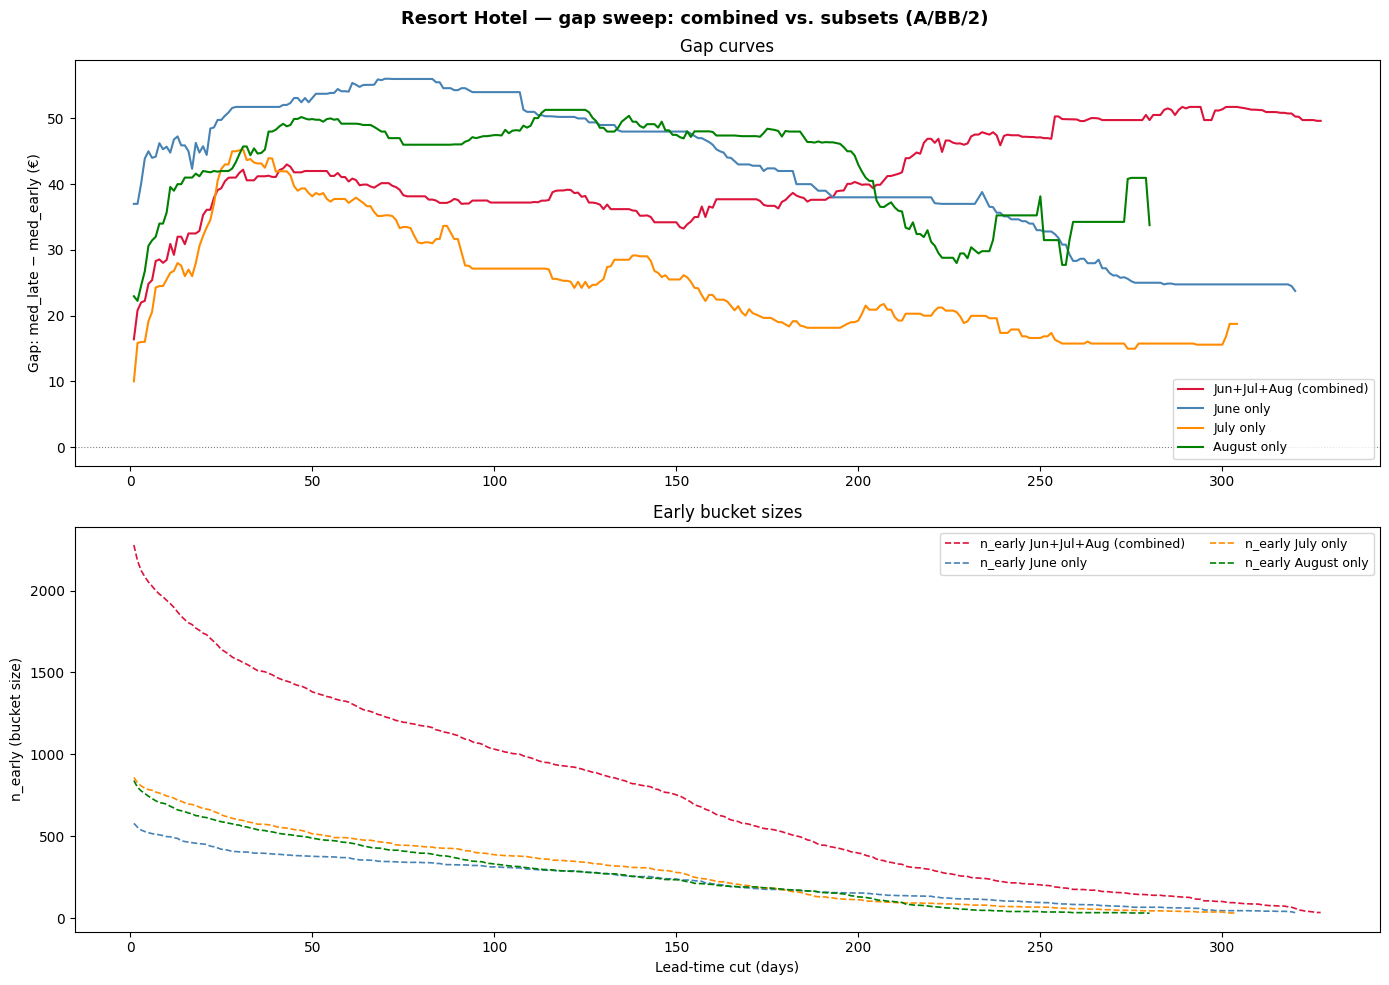

In [10]:
def plot_heterogeneity(hotel, subsets, colors, min_n=30):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f"{hotel} — gap sweep: combined vs. subsets ({rooms}/{meals}/{adults})",
                 fontsize=13, fontweight="bold")

    for label, months in subsets.items():
        s = gap_sweep(canon_subset(hotel, months), min_n=min_n)
        if s.empty:
            continue
        axes[0].plot(s["cut"], s["gap"], color=colors[label], linewidth=1.5, label=label)
        axes[1].plot(s["cut"], s["n_early"], color=colors[label], linewidth=1.2,
                     linestyle="--", label=f"n_early {label}")

    axes[0].axhline(0, color="grey", linestyle=":", linewidth=0.8)
    axes[0].set_ylabel("Gap: med_late − med_early (€)")
    axes[0].set_title("Gap curves")
    axes[0].legend(fontsize=9)

    axes[1].set_xlabel("Lead-time cut (days)")
    axes[1].set_ylabel("n_early (bucket size)")
    axes[1].set_title("Early bucket sizes")
    axes[1].legend(fontsize=9, ncol=2)

    plt.tight_layout()
    plt.show()

plot_heterogeneity(
    "Resort Hotel",
    subsets={
        "Jun+Jul+Aug (combined)": [6, 7, 8],
        "June only": [6], "July only": [7], "August only": [8],
    },
    colors={
        "Jun+Jul+Aug (combined)": "crimson",
        "June only": "steelblue", "July only": "darkorange", "August only": "green",
    },
)

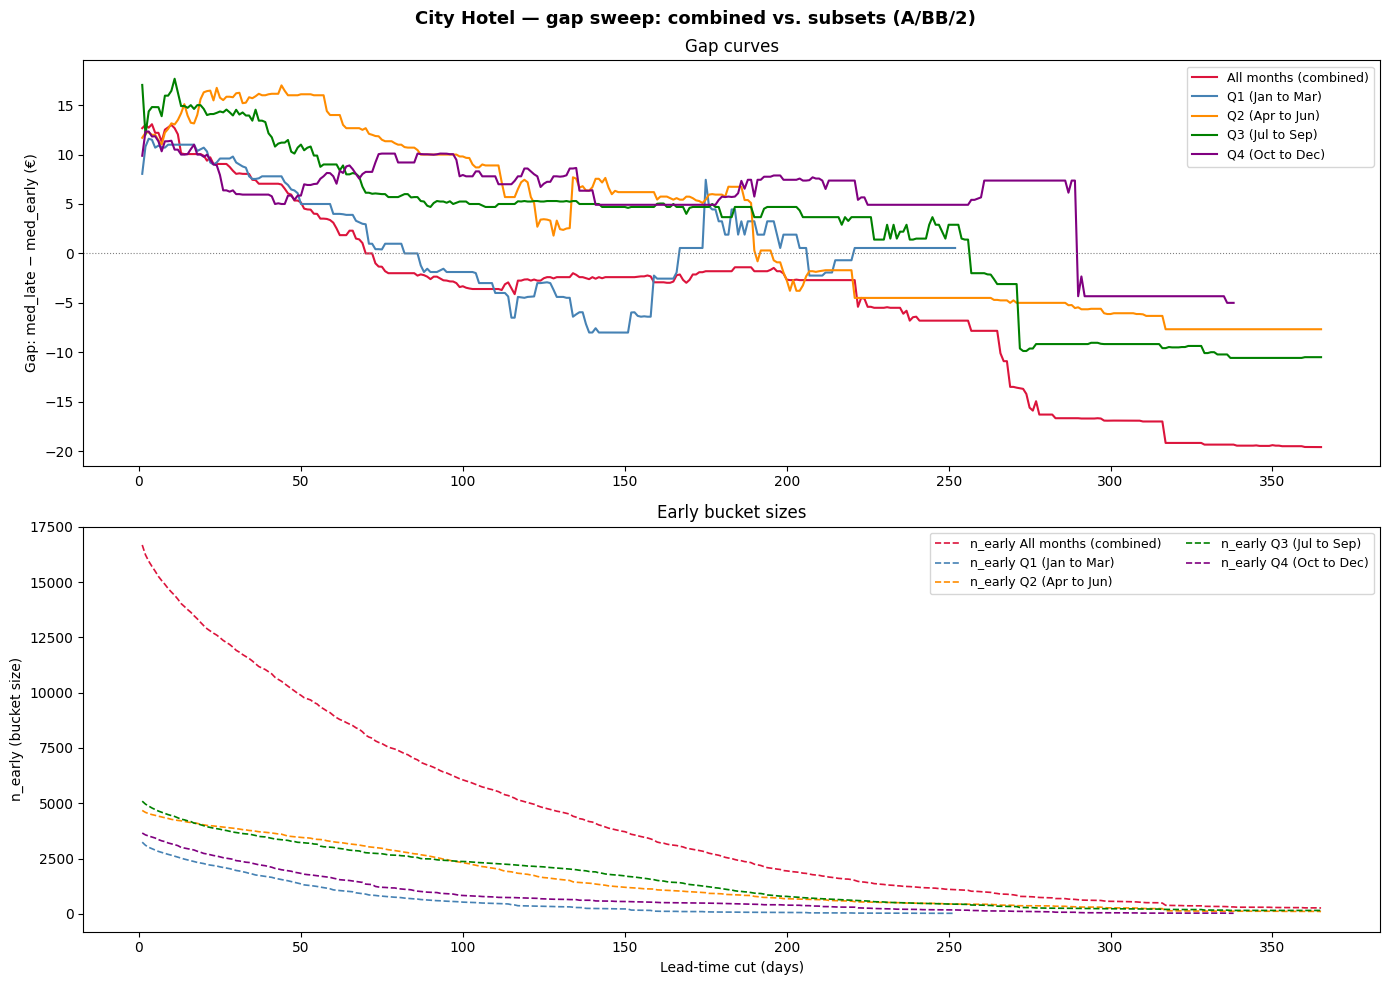

In [11]:
plot_heterogeneity(
    "City Hotel",
    subsets={
        "All months (combined)": None,
        "Q1 (Jan to Mar)": [1, 2, 3], "Q2 (Apr to Jun)": [4, 5, 6],
        "Q3 (Jul to Sep)": [7, 8, 9], "Q4 (Oct to Dec)": [10, 11, 12],
    },
    colors={
        "All months (combined)": "crimson",
        "Q1 (Jan to Mar)": "steelblue", "Q2 (Apr to Jun)": "darkorange",
        "Q3 (Jul to Sep)": "green", "Q4 (Oct to Dec)": "purple",
    },
)

The subset curves confirm that the Resort gap is a genuine lead-time effect. June, July and August each produce a clearly positive gap across the full range, all tracking the combined curve in sign and broad shape. July is the weakest of the three but stays well above zero, and no single month drives the result. We can therefore size the advance-sale cut on the combined peak data with confidence.

For City Hotel the picture is more nuanced. At short lead times, the region where City's pooled gap is positive, all four quarters agree, each showing a premium of roughly €8 to €17. The short-horizon late premium is therefore robust rather than a seasonal artefact. At longer cuts the quarters diverge, and the combined curve falls below every individual quarter, reaching about €-20 where the quarters bottom out around €-5 to €-10. This deep negative tail is an aggregation effect rather than a within-period signal, which reinforces that City's usable advance-sale boundary belongs in the short-horizon window.

### Minimum Volume Thresholds

A median is only trustworthy if it rests on enough observations. Before selecting a cut, we define the minimum for each bucket to hold at least 5% of the hotel's canonical bookings. The same 5% rule is applied to both hotels, which scales the threshold to each property's size.

In [12]:
min_n = {
    hotel: int(round(0.05 * (canon["hotel"] == hotel).sum()))
    for hotel in hotels
}

display(pd.DataFrame({
    "Hotel": list(min_n),
    "Canonical bookings": [int((canon["hotel"] == h).sum()) for h in min_n],
    "5% min_n": list(min_n.values()),
}))

,Hotel,Canonical bookings,5% min_n
0,Resort Hotel,8600,430
1,City Hotel,17506,875


### Determination of Optimal Lead Time Cut-offs

We evaluate three candidate cuts per hotel, each optimising a different criterion. The plateau center, a stable cut within 95% of the maximum gap; the maximum-gap cut; and the most balanced split, closest to equal bucket sizes. 

Candidates are only sought where the gap is positive, since a cut at which late bookers pay no premium carries no advance-sale meaning. For Resort Hotel this covers essentially the whole peak sweep. For City Hotel it restricts the search to the short-horizon window identified earlier.

In [13]:
sweep_data = {
    "Resort Hotel": canon_subset("Resort Hotel", peak_months.get("Resort Hotel")),  # peak months
    "City Hotel":   canon_subset("City Hotel",   peak_months.get("City Hotel")),    # None: full year
}

def select_candidates(sweep):
    plateau = sweep[sweep["gap"] >= 0.95 * sweep["gap"].max()]          #helper funktion für unsere Kandidaten
    return {
        "plateau": int(round(plateau["cut"].median())),
        "max_gap": int(sweep.loc[sweep["gap"].idxmax(), "cut"]),
        "balance": int(sweep.loc[(sweep["n_early"] - sweep["n_late"]).abs().idxmin(), "cut"]),
    }

picks = {}
rows = []
for hotel in hotels:
    sweep = gap_sweep(sweep_data[hotel], min_n=min_n[hotel])
    pos = sweep[sweep["gap"] > 0]                 # nur positiver bereich für die suche
    cand = select_candidates(pos)
    picks[hotel] = {"sweep": sweep, **cand}

    for label in ["plateau", "max_gap", "balance"]:
        cut = cand[label]
        r = sweep.loc[(sweep["cut"] - cut).abs().idxmin()]
        rows.append({
            "Hotel": hotel, "Criterion": label, "Cut (d)": cut,
            "Gap (€)": round(r["gap"], 1),
            "med_early": round(r["med_early"], 1),
            "med_late":  round(r["med_late"], 1),
            "n_early": int(r["n_early"]), "n_late": int(r["n_late"]),
        })

display(pd.DataFrame(rows))

,Hotel,Criterion,Cut (d),Gap (€),med_early,med_late,n_early,n_late
0,Resort Hotel,plateau,44,42.6,107.9,150.5,1440,1044
1,Resort Hotel,max_gap,43,43.0,108.0,151.0,1447,1037
2,Resort Hotel,balance,68,39.8,105.2,145.0,1244,1240
3,City Hotel,plateau,8,12.5,91.5,104.0,14895,2611
4,City Hotel,max_gap,4,13.1,91.9,105.0,15706,1800
5,City Hotel,balance,63,1.8,92.6,94.5,8730,8776


For Resort Hotel the three candidates converge closely. The plateau center falls at 44 days and the maximum gap at 43 days, a one-day difference that confirms the choice sits firmly inside the stable region rather than on a spike. The balanced split at 68 days trades a marginal reduction in gap (€39.8 versus €43.0) for near-equal buckets. We select 43 days, the maximum-gap cut, with well-populated buckets on both sides (n_early = 1,447, n_late = 1,037).

For City Hotel the gap-based criteria point to a much shorter cut of 4-8 days, reflecting that City's late premium is confined to the final stretch before arrival. The balanced split, by contrast, lands at 63 days, right at the point where the gap has already decayed to zero. Because a balanced cut here would carry no price premium, we reject it and adopt the plateau cut of 8 days as City's advance-sale boundary.

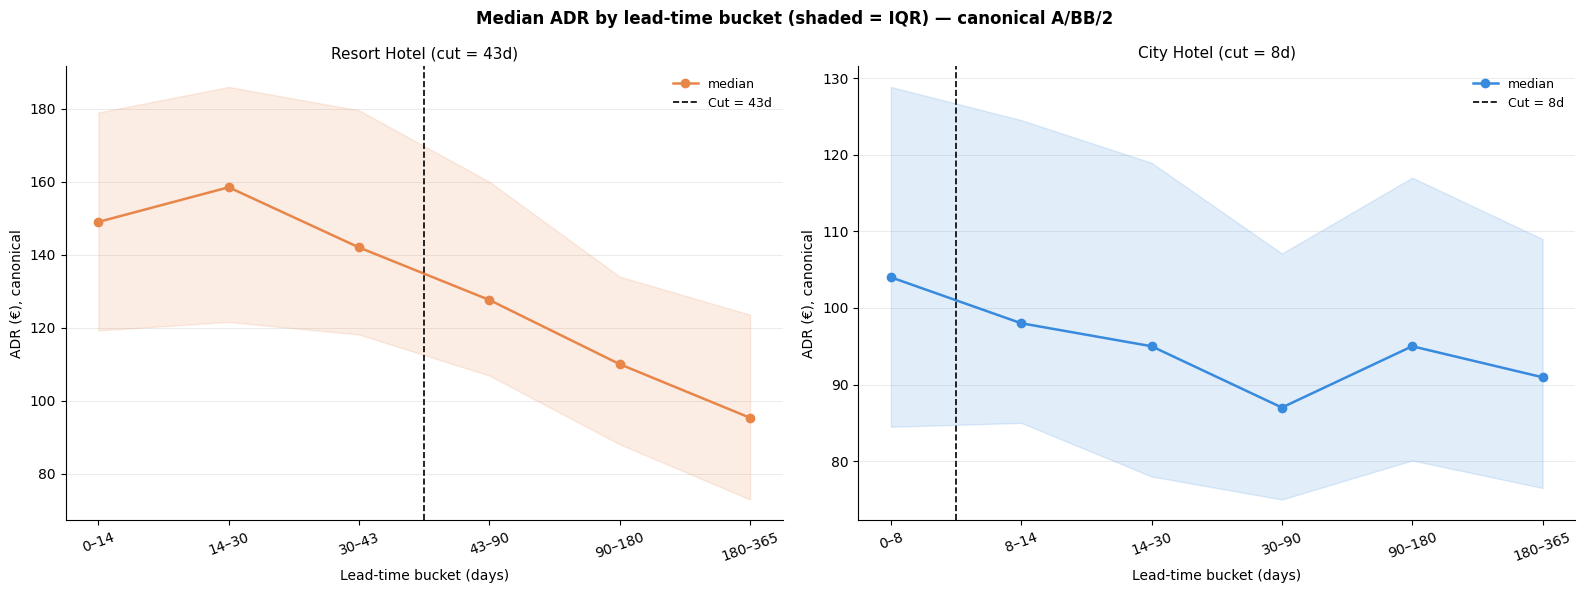

In [14]:
def make_bins(cut, base=(0, 14, 30, 90, 180, 365)): #bin kanten + cut als exakte grenze mit passenden labels
    edges = sorted(set(base) | {cut})
    labels = [f"{lo}–{hi}" for lo, hi in zip(edges[:-1], edges[1:])]
    return edges, labels

def bucket_plot(ax, hotel, cut, color):
    edges, labels = make_bins(cut)
    d = canon_subset(hotel, peak_months.get(hotel)).copy()
    d["lt_bucket"] = pd.cut(d["lead_time"], bins=edges, labels=labels, right=False)

    agg = (
        d.groupby("lt_bucket", observed=True)["adr"]
        .agg(median="median",
             q25=lambda x: x.quantile(.25),
             q75=lambda x: x.quantile(.75),
             n="count")
        .reset_index()
    )

    x = range(len(agg))
    ax.plot(x, agg["median"], color=color, marker="o", markersize=6,
            linewidth=1.8, label="median")
    ax.fill_between(x, agg["q25"], agg["q75"], color=color, alpha=0.15)
    ax.axvline(edges.index(cut) - 0.5, color="black", linestyle="--",
               linewidth=1.2, label=f"Cut = {cut}d")

    ax.set_title(f"{hotel} (cut = {cut}d)", fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20)
    ax.set_xlabel("Lead-time bucket (days)")
    ax.set_ylabel("ADR (€), canonical")
    ax.legend(fontsize=9, frameon=False)
    ax.yaxis.grid(True, linewidth=0.4, color="gainsboro")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# welcher cut pro hotel in den plot soll 
chosen_cut = {
    "Resort Hotel": picks["Resort Hotel"]["max_gap"],
    "City Hotel":   picks["City Hotel"]["plateau"],
}
hotel_colors = {"City Hotel": "#378ADD", "Resort Hotel": "#E8864A"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Median ADR by lead-time bucket (shaded = IQR) — canonical A/BB/2",
             fontsize=12, fontweight="bold")

for ax, hotel in zip(axes, hotels):
    bucket_plot(ax, hotel, chosen_cut[hotel], hotel_colors[hotel])

plt.tight_layout()
plt.show()

The lead-time bucket plot shows how strongly each hotel can price by booking timing.

For Resort Hotel the effect is strong and clean. Every bucket below the 43-day cut stays near rack level, between €142 and €159, with the peak in the 14 to 30 day window. A guest booking within six weeks of arrival pays close to the top rate regardless of exactly when they book. Past the cut the price falls steadily with lead time andd the IQR bands tighten alongside, so the deepest discounts are also the most consistent. The cut therefore separates a uniformly high-fare late segment from a progressively discounted early one, which is exactly the structure advance-sale pricing relies on.

For City Hotel the same mechanism is barely present. The cut sits at just 8 days and the step there is small, from about €105 in the final days to €99 just beyond. Further out the curve does not decline cleanly at all. It dips to a trough near €87 around 30 to 90 days and then climbs back to roughly €95, so the lowest fares fall in the middle of the booking horizon rather than at the longest lead times. There is no monotonic early discount to capture. City can charge a slight last-minute premium, but booking timing is not a lever it can use to reward early commitment.

### Segment Characterization

So far we have established a timing split. Within Resort's high season, a 43-day cut separates a consistently high-fare late segment from a progressively discounted early one, a roughly €43 gap that survives the per-month heterogeneity check.

A price gap between two lead-time buckets is only a usable lever if those buckets map onto recognisable, addressable guest segments. A price rate Clara cannot target is lost possible revenue. We need to know who sits on each side and through which channel they arrive, so that "cap the advance bucket" becomes a concrete action, such as repricing or limiting a specific channel or contract. We therefore describe each side of the cut by its customer-type and distribution-channel mix. This serves two purposes. 

First, it corroborates the timing story on an independent axis. If the early bucket is a genuinely different kind of demand, the segmentation has real structure rather than a bare statistical gap. 
Second, it identifies the levers that actually move the advance bucket. We keep the same population the cut was measured on, so the description matches the gap it explains.

We run Resort first. Because City's lead-time lever turned out to be weak, its segment split is examined mainly to confirm that no strong, distinct advance segment exists there, and the per-hotel comparison follows.

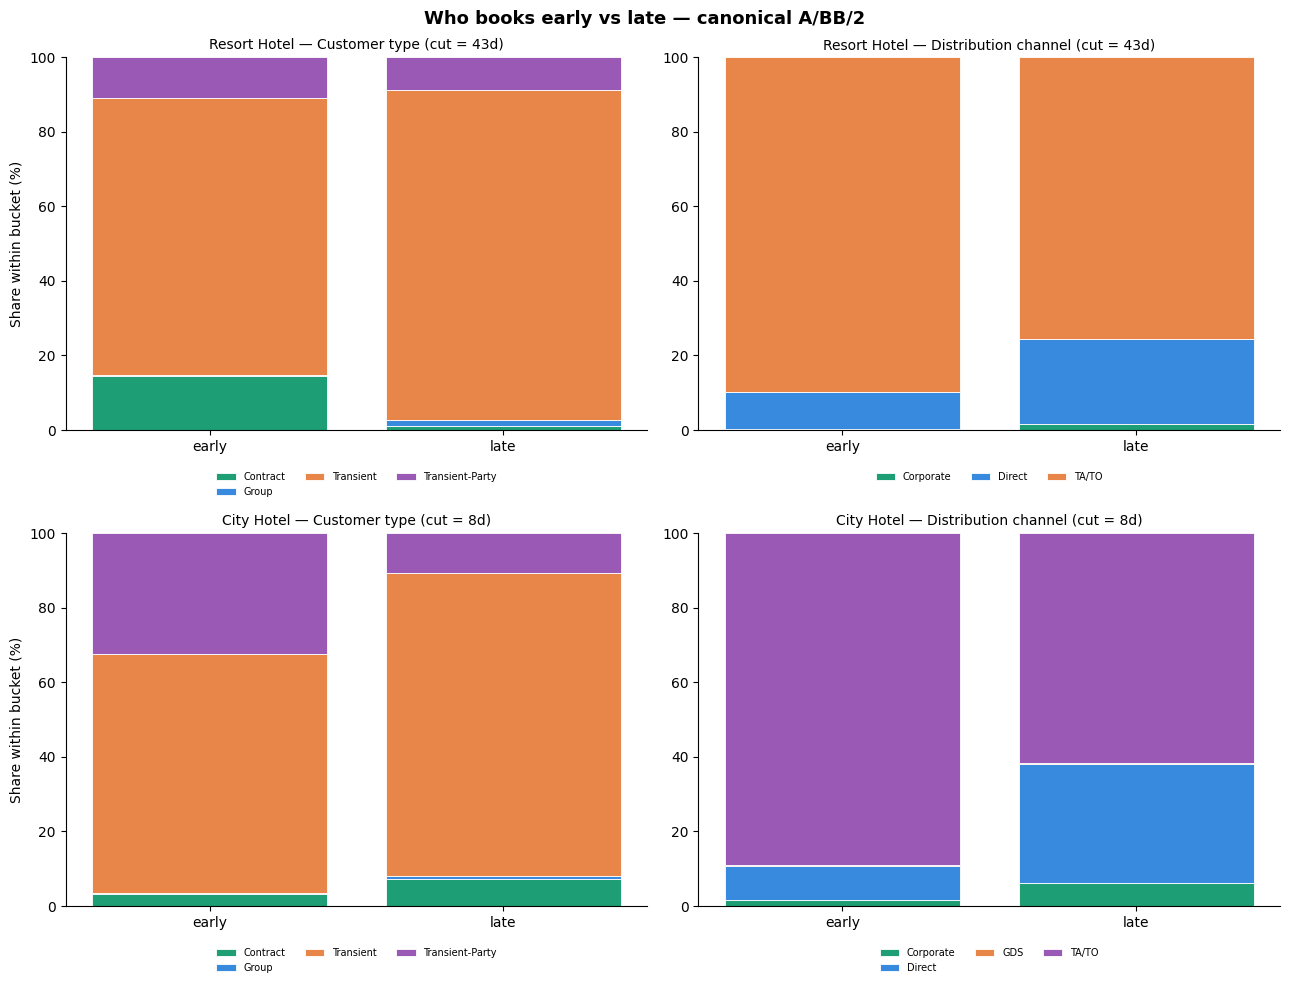

Bucket sizes (n)


,Resort Hotel,City Hotel
side,,
early,1447,14895
late,1037,2611


Customer type — % within side


customer_type       Contract  Group  Transient  Transient-Party
hotel        side                                              
Resort Hotel early      14.6    0.1       74.5             10.9
             late        1.1    1.5       88.6              8.8
City Hotel   early       3.2    0.3       64.2             32.3
             late        7.2    0.7       81.3             10.8

Distribution channel — % within side


distribution_channel  Corporate  Direct  TA/TO  GDS
hotel        side                                  
Resort Hotel early          0.3     9.7   89.9  0.0
             late           1.5    22.9   75.6  0.0
City Hotel   early          1.6     9.2   89.1  0.0
             late           6.3    31.9   61.7  0.1

In [15]:
palette = ["#1D9E75", "#378ADD", "#E8864A", "#9B59B6", "#E24B4A", "#7F8C8D"]

seg_cut = {"Resort Hotel": 43, "City Hotel": 8}   

# segmentierte daten pro hotel einmal bauen
seg = {}
for h in hotels:
    d = canon_subset(h, peak_months.get(h)).copy()
    d["side"] = np.where(d["lead_time"] >= seg_cut[h], "early", "late")
    seg[h] = d

#2x2 grid: zeilen = hotels, spalten = customer_type / channel
dims = [("customer_type", "Customer type"), ("distribution_channel", "Distribution channel")]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Who books early vs late — canonical A/BB/2", fontsize=13, fontweight="bold")

for r, hotel in enumerate(hotels):
    for c, (col, title) in enumerate(dims):
        ax = axes[r, c]
        mix = (seg[hotel].groupby("side")[col].value_counts(normalize=True)
                 .unstack().fillna(0) * 100).reindex(["early", "late"])
        bottom = np.zeros(len(mix))
        for i, cat in enumerate(mix.columns):
            ax.bar(mix.index, mix[cat], bottom=bottom, label=cat,
                   color=palette[i % len(palette)], edgecolor="white", linewidth=0.6)
            bottom += mix[cat].to_numpy()
        ax.set_title(f"{hotel} — {title} (cut = {seg_cut[hotel]}d)", fontsize=10)
        ax.set_ylim(0, 100)
        if c == 0:
            ax.set_ylabel("Share within bucket (%)")
        ax.legend(frameon=False, fontsize=7, loc="upper center",
                  bbox_to_anchor=(0.5, -0.09), ncol=3)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# tabellen: beide hotels nebeneinander
def mix_table(col):
    parts = []
    for h in hotels:
        m = (seg[h].groupby("side")[col].value_counts(normalize=True)
               .unstack().fillna(0) * 100).reindex(["early", "late"]).round(1)
        m.index = pd.MultiIndex.from_product([[h], m.index], names=["hotel", "side"])
        parts.append(m)
    return pd.concat(parts).fillna(0)

bucket_sizes = pd.DataFrame({h: seg[h]["side"].value_counts() for h in hotels}).reindex(["early", "late"])

print("Bucket sizes (n)")
display(bucket_sizes)

print("Customer type — % within side")
display(mix_table("customer_type"))

print("Distribution channel — % within side")
display(mix_table("distribution_channel"))

The lead-time split does more than separate two price levels. It separates two recognisable kinds of demand, which is what makes the gap addressable.

In the Resort Hotel, both sides are majority Transient, as expected for a leisure resort, so the segmentation shows up in the minority mix rather than a change of dominant type. On the customer axis, Contract demand jumps from 1.1% of late bookers to 14.6% of early ones, so the little contracted or block demand that exists concentrates in the advance window. On the channel axis, early bookings run overwhelmingly through TA/TO (89.9% versus 75.6% late), while late bookings skew Direct (22.9% versus 9.7%). The late bucket is therefore close to pure Transient or Direct booking inside 43 days at the 151 median, while the early bucket is a transient base carrying a distinct Contract and TA/TO tail booking 43 or more days out at a 108 median. The advance discount is partly targetable. The slice Clara most directly controls is the contracted and TA/TO volume she releases early.

In the City Hotel, the composition shifts clearly too, but in a different direction. The last-minute bucket under 8 days is far more Direct (31.9% versus 9.2%) and Corporate (6.3% versus 1.6%), while the advance bucket runs heavily through TA/TO (89.1%) and carries more Transient-Party bookings (32.3% versus 10.8%). City's advance window is leisure parties booking ahead through agents, and its last-minute window is lone Direct and Corporate guests. The segment is identifiable. What it does not carry is a price premium, since City's late ADR sits barely above its early median (91.5 vs 104). The last-minute business segment is real but cannot be monetised through lead-time pricing.

The two hotels call for opposite instincts. At Resort, late bookers pay a large premium, so rooms are worth protecting from the advance discount. At City, the identifiable last-minute segment pays little more than early bookers, so there is little revenue to protect and the advance allocation can stay generous. 

### Analysis of Temporal Booking Patterns

The cut tells us where to split early from late and who sits on each side. To turn that into an advance-sale limit we need one more quantity. How much advance demand actually exists. We read this from the reverse-cumulative booking curve, the share of the final realised bookings already on hand at each lead time. Its value at the cut, F_early, is the share of demand booking at lead time at or above the cut, and it bounds how large the advance pool can be.

F_early is computed on all realised bookings, not just the canonical tuple, because the advance limit is allocated over the whole inventory and a volume share does not need the homogenisation the price signal required. The canonical value is reported alongside as a robustness check.

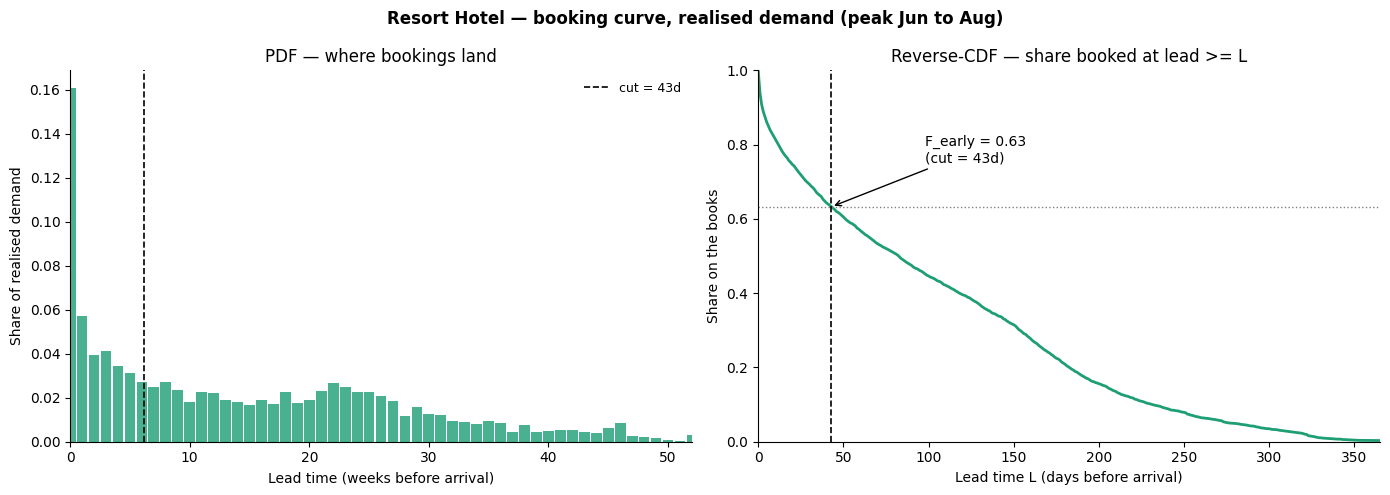

Resort Hotel: F_early(>= 43d) all=0.633 | canonical=0.583 | median lead 82d, n=8432


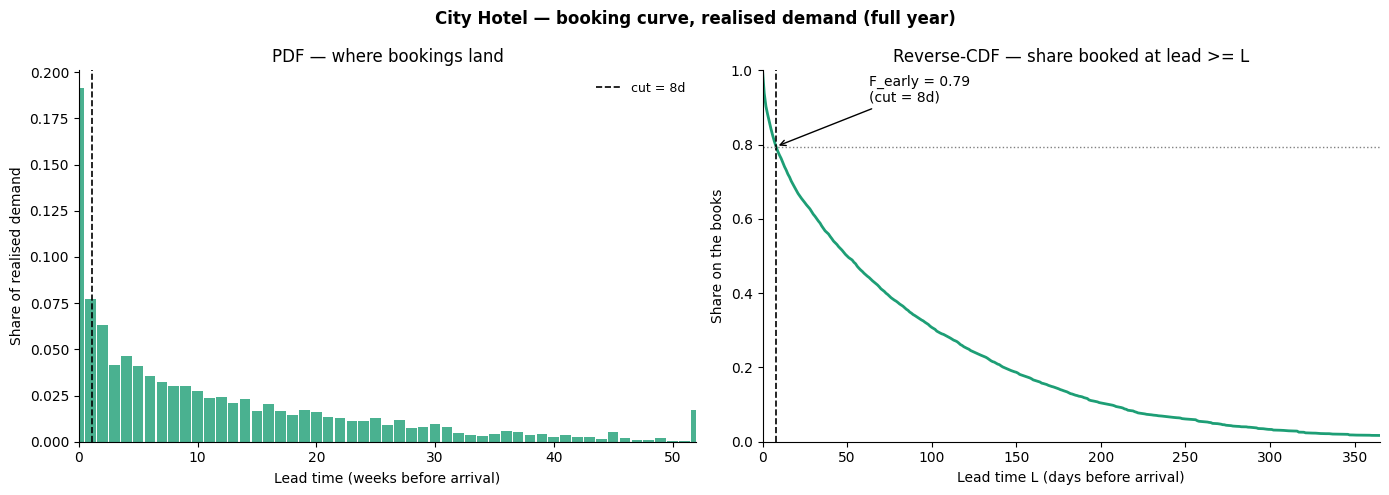

City Hotel: F_early(>= 8d) all=0.795 | canonical=0.851 | median lead 50d, n=46228


np.float64(0.7947347927662888)

In [16]:
def hotel_subset(hotel, months=None):
    df = realised[realised["hotel"] == hotel]       #helper: holt alle realisierten bookings eines hotels
    if months is not None:
        df = df[df["arrival_date"].dt.month.isin(months)]
    return df

cand_df = pd.DataFrame(rows)

def fares_at_cut(hotel, cut):                               #helper: holt med_early (p_L) und med_late (p_H) am cut, aus der kandidaten-tabelle.
    r = cand_df[(cand_df["Hotel"] == hotel) & (cand_df["Cut (d)"] == cut)].iloc[0]
    return r["med_early"], r["med_late"]

def booking_curve(hotel, cut, color="#1D9E75"):
    pop   = hotel_subset(hotel, peak_months.get(hotel))   # alle zimmer (volumen über ganzes inventar)
    pop_c = canon_subset(hotel, peak_months.get(hotel))   # kanonisch, nur als robustness

    F_early   = (pop["lead_time"]   >= cut).mean()
    F_early_c = (pop_c["lead_time"] >= cut).mean()

    months_lbl = "peak Jun to Aug" if peak_months.get(hotel) else "full year"
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{hotel} — booking curve, realised demand ({months_lbl})",
                 fontsize=12, fontweight="bold")

    weeks = (pop["lead_time"].clip(upper=365) // 7)
    w_share = weeks.value_counts(normalize=True).sort_index()
    ax = axes[0]
    ax.bar(w_share.index, w_share.values, color=color, alpha=0.8, width=0.9)
    ax.axvline(cut / 7, color="black", linestyle="--", linewidth=1.2, label=f"cut = {cut}d")
    ax.set_title("PDF — where bookings land")
    ax.set_xlabel("Lead time (weeks before arrival)")
    ax.set_ylabel("Share of realised demand")
    ax.set_xlim(0, 52)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    grid = np.arange(0, 366)
    surv = [(pop["lead_time"] >= L).mean() for L in grid]
    ax.plot(grid, surv, color=color, linewidth=2)
    ax.axvline(cut, color="black", linestyle="--", linewidth=1.2)
    ax.axhline(F_early, color="grey", linestyle=":", linewidth=1)
    ax.annotate(f"F_early = {F_early:.2f}\n(cut = {cut}d)",
                xy=(cut, F_early), xytext=(cut + 55, min(F_early + 0.12, 0.95)),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
    ax.set_title("Reverse-CDF — share booked at lead >= L")
    ax.set_xlabel("Lead time L (days before arrival)")
    ax.set_ylabel("Share on the books")
    ax.set_xlim(0, 365); ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f"{hotel}: F_early(>= {cut}d) all={F_early:.3f} | canonical={F_early_c:.3f} | "
          f"median lead {pop['lead_time'].median():.0f}d, n={len(pop)}")
    return F_early

booking_curve("Resort Hotel", 43)
booking_curve("City Hotel", 8)

The booking curve says how much advance demand exists, not how much we should sell in advance. That depends on the price gap and on how uncertain late demand is. With two fare classes, where the low fare (early) books first and the high fare (late) books close to arrival, Littlewood's rule gives the optimal protection level y*, the number of rooms to reserve for late high-fare demand:

$$
P(D_H > y^*) = \frac{p_L}{p_H} \qquad \text{and} \qquad y^* = F^{-1}\left(1 - \frac{p_L}{p_H}\right)
$$


where $D_H$ is late demand, $p_L$ and $p_H$ are the early and late fares, and $F_H$ is the CDF of late demand. 

The idea is to accept an early low-fare booking only while the certain early revenue exceeds the expected value of holding that room for a late high-fare guest. We protect the last room whose chance of being claimed by a late booker, weighted by the fare ratio, still beats selling it early. 

We estimate $D_H$ from realised late bookings per night of all room types and the fares are the canonical medians at the cut.

Resort Hotel:
p_L=108.0, p_H=151.0, ratio=0.715
protect 9 rooms/night (late median 12, nights=246)
P(late >= 9) = 0.760 >= ratio  |  P(late >= 10) = 0.654 < ratio


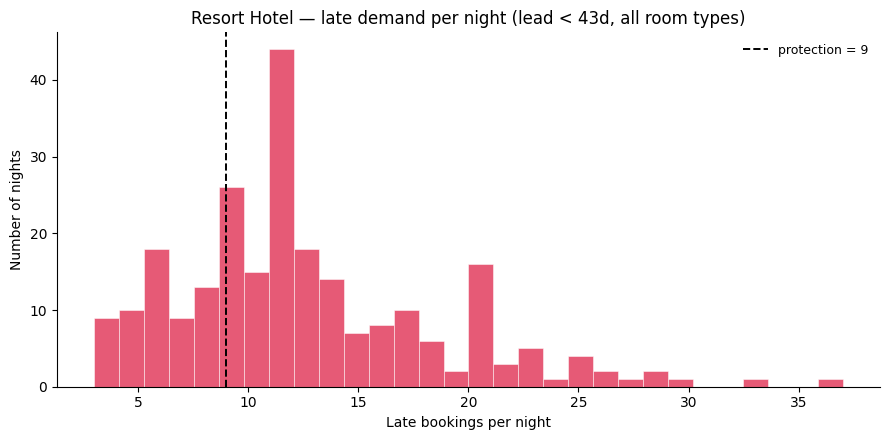

City Hotel:
p_L=91.5, p_H=104.0, ratio=0.880
protect 5 rooms/night (late median 11, nights=772)
P(late >= 5) = 0.892 >= ratio  |  P(late >= 6) = 0.843 < ratio


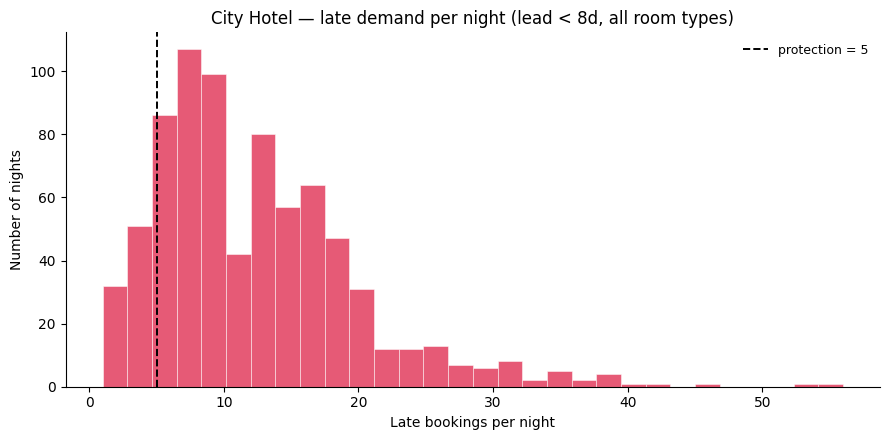

(5, np.float64(0.8798076923076923))

In [17]:
def littlewood(hotel, cut, plot=True):
    pop = hotel_subset(hotel, peak_months.get(hotel))
    p_L, p_H = fares_at_cut(hotel, cut)
    ratio = p_L / p_H

    late_per_night = pop[pop["lead_time"] < cut].groupby("arrival_date").size()

    y_star = 0
    for x in range(1, int(late_per_night.max()) + 1):
        if (late_per_night >= x).mean() >= ratio:
            y_star = x
        else:
            break

    # wahrscheinlichkeiten am protection level: das geschützte und das erste verworfene zimmer
    p_at   = (late_per_night >= y_star).mean()
    p_next = (late_per_night >= y_star + 1).mean()

    print(f"{hotel}:")
    print(f"p_L={p_L:.1f}, p_H={p_H:.1f}, ratio={ratio:.3f}")
    print(f"protect {y_star} rooms/night "
          f"(late median {late_per_night.median():.0f}, nights={len(late_per_night)})")
    print(f"P(late >= {y_star}) = {p_at:.3f} >= ratio  |  "
          f"P(late >= {y_star + 1}) = {p_next:.3f} < ratio")

    if plot:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.hist(late_per_night, bins=30, color="crimson", alpha=0.7,
                edgecolor="white", linewidth=0.5)
        ax.axvline(y_star, color="black", linestyle="--", linewidth=1.4,
                   label=f"protection = {y_star}")
        ax.set_title(f"{hotel} — late demand per night (lead < {cut}d, all room types)")
        ax.set_xlabel("Late bookings per night")
        ax.set_ylabel("Number of nights")
        ax.legend(frameon=False, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout(); plt.show()

    return y_star, ratio

littlewood("Resort Hotel", 43)
littlewood("City Hotel", 8)

For Resort the fare ratio is     $p_L/p_H$ = 108/151 = 0.715. A room is worth protecting as long as a late booker is at least 71.5% likely to claim it. That holds up to 9 rooms: P(late ≥ 9) = 0.76 clears the bar, the 10th room (P = 0.654) does not. Clara should reserve about 9 rooms per peak night for late high-fare demand and release the rest for advance sale. With a median of 12 late bookings per night, this protection sits comfortably inside typical late demand.

For City the fare ratio is much higher,  $p_L/p_H$ = 0.88, because the late premium is small. A higher bar means a room is only worth protecting when late demand fills it with near certainty, so the optimal protection collapses to 5 rooms. This is expected from the weak-lever finding. With almost no premium to defend, City should sell advance generously and protect very little.

### Limitations for Q1

Two assumptions qualify the protection levels above.

First, late demand is measured from realised bookings only. On any night that sold out, further late requests were turned away and never entered the data, so the observed late demand is capped by capacity rather than reflecting true demand. The protection levels are therefore conservative lower bounds. The real optimum may sit slightly higher.

Second, the fare ratio and the demand volume are drawn from different populations, by design. 

$pL​/pH$​ comes from the canonical tuple A/BB/2, where room type, meal plan, and party size are held constant, so the price signal is clean and not distorted by a shifting room mix. The late-demand distribution, by contrast, is counted over all room types, because the protection level is a number of real rooms allocated across the whole inventory. This combination assumes the canonical price ratio is representative of the property as a whole. If other room types carried a markedly different early-to-late ratio, the recommended level would shift accordingly.

## §Q2 · Derive Overbooking Parameters

Clara wants to overbook to mitigate late cancellations and no-shows â€” but walk-aways hurt guest satisfaction and brand image.

- Use historical data to estimate a **robust overbooking buffer** for each hotel. How many extra bookings can Clara accept without incurring frequent walk-aways?
- Make any **trade-offs and assumptions explicit** (walk cost, tolerated walk frequency, independence of cancellations, â€¦).

### Methodological Framework for Overbooking Optimization

Overbooking is a capacity-risk problem rather than a pricing optimization challenge. While the analysis in the previous section (Q1) was intentionally calibrated strictly on realized stays to isolate undisturbed pricing signals, inventory protection requires modeling the variance between accepted reservations and actual physical check-ins.

To derive a robust overbooking buffer, we deploy a two-stage analytical framework:

1. **Empirical Diagnostics:** Building upon the structural baseline established in Q1, where the strong monotonic relationship between booking lead time and cancellation probability was demonstrated, this section expands the view by cross-referencing these insights with intermediation channels to map the comprehensive risk structure.

2. **Predictive Modeling:** A cancellation model that estimates individual cancel probabilities. These probabilities are subsequently used to translate booking-level risk into expected check-ins and walk-away risk.

Accounting for the specific booking mix is essential. Utilizing a single, pooled average cancellation rate would severely misestimate risk, as it ignores the compositional variance between long-lead segments, short-lead direct bookings, corporate clients, and leisure guests.

From an economic perspective, the determination of the overbooking buffer represents a classic Newsvendor optimization problem, balancing the trade-off between spoilage and spillage. 

The objective is not to eliminate risk completely, but to choose a controlled buffer that recovers revenue from predictable cancellations while keeping walk-aways to a defined tolerance threshold.

#### Empirical Cancellation Diagnostics

Before fitting the predictive model, we evaluate the historical data to map the structural drivers of cancellation risk. These empirical baseline rates serve as a diagnostic sanity check for the following predictive framework but do not directly dictate the final buffer size.

,hotel,bookings,cancel_rate_pct
0,City Hotel,79330,41.7
1,Resort Hotel,40060,27.8


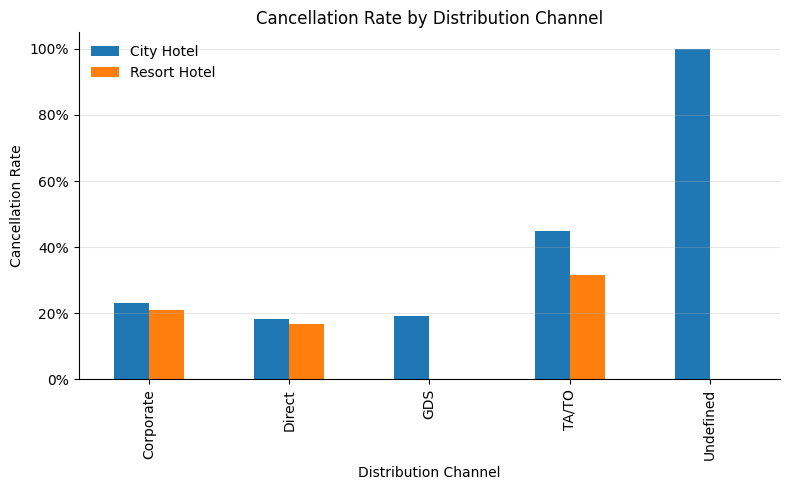

In [18]:
# Empirical cancellation diagnostics
# Focusing on baseline rates and the unique distribution channel signal

from IPython.display import display, Markdown

q2_df = bookings.copy()

# Summary table for a general overview
hotel_cancel_summary = (
    q2_df
    .groupby("hotel")
    .agg(
        bookings=("is_canceled", "size"),
        cancel_rate=("is_canceled", "mean"),
    )
    .reset_index()
)

hotel_cancel_summary["cancel_rate_pct"] = (
    hotel_cancel_summary["cancel_rate"] * 100
).round(1)

display(hotel_cancel_summary[["hotel", "bookings", "cancel_rate_pct"]])

# Compute channel cancellations (lead time is omitted here to avoid redundancy with Q1)
channel_cancel = (
    q2_df
    .groupby(["hotel", "distribution_channel"])
    .agg(
        bookings=("is_canceled", "size"),
        cancel_rate=("is_canceled", "mean"),
    )
    .reset_index()
)

# Plotting only the distribution channel risk
fig, ax = plt.subplots(figsize=(8, 5))

channel_pivot = channel_cancel.pivot(
    index="distribution_channel",
    columns="hotel",
    values="cancel_rate",
)

channel_pivot.plot(kind="bar", ax=ax)
ax.set_title("Cancellation Rate by Distribution Channel")
ax.set_xlabel("Distribution Channel")
ax.set_ylabel("Cancellation Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Empirical Insights and the Necessity of Predictive Modeling

The empirical diagnostics show why inventory protection requires a nuanced approach rather than the application of a singular, pooled average cancellation rate. Because cancellation behavior varies significantly across temporal horizons and distribution channels, identical booking volumes can carry different check-in risks depending on the specific composition of the current reservations.

While these descriptive rates provide a valuable operational sanity check, they are fundamentally insufficient for direct decision-making. If the subsequent predictive framework assigns higher risk to long-lead or channel-specific demand, these signals must be structurally identifiable within the baseline data. However, these aggregate empirical rates cannot directly dictate the final overbooking buffer because they are too aggregated.

The operational decision is inherently forward-looking and constrained by physical capacity. Determining the precise number of reservations to accept while keeping walk-aways under the threshold. Addressing this requires transitioning from static, historical cancellation rates to a, probability-based risk model. Consequently, while the empirical analysis maps the underlying risk pattern, the predictive model-based frontier provides the mathematical foundation to size the optimal buffer.

### From Predictions to Expected Inventory Occupancy

To operationalize the predictive framework for inventory protection, individual booking-level probabilities must be translated into capacity based metrics. The core idea is that reservations cannot be treated as equally risky. A booking with a high cancellation probability contributes structurally less to final physical occupancy than a resilient, low-probability reservation.

Therefore, each individual booking i is converted into an expected arrival contribution, denoted as: $$E[\text{Show}_i] = 1 - p_{\text{cancel}, i}$$


where $p_{cancel}$ represents the cancellation probability predicted by the model. Aggregating these individual contributions across the entire book of current reservations gives the effective, cancellation-adjusted expected occupancy:


$$\hat{Q}_{\text{eff}} = \sum_{i} (1 - p_{\text{cancel}, i})$$

This formulation creates the necessary mathematical bridge from prediction to overbooking decisions. While the raw booking count reflects nominal volume, $\hat{Q}_{\text{eff}}$ quantifies the true expected physical capacity utilization. The variance between nominal bookings and $\hat{Q}_{\text{eff}}$ represents the room available for overbooking strategies.

However, capacity management cannot rely on point estimates alone. The expected occupancy $\hat{Q}_{\text{eff}}$ only captures the mean arrival volume. For operational overbooking decisions, the distribution of possible arrivals must be considered explicitly. In particular, we must quantify the probability that realized arrivals exceed physical capacity. The final overbooking buffer is therefore determined from a walk-away risk frontier.

### Predictive Modeling and Probability Calibration

We train a Logistic Regression model utilizing a comprehensive feature set spanning temporal lead times, operational volume indicators and categorical channel segmentation. Missing numeric values are handled via median imputation, and features are standardized to ensure numerical stability.

The choice of evaluation metrics must strictly align with the operational goal. Because the buffer calculation uses the probability directly, calibration matters more than a pure ranking metric. We therefore evaluate classification performance using a balanced suite of metrics, prioritizing the Brier Score and non-parametric calibration curves to verify that the predicted probabilities can be trusted as direct numerical inputs for sizing the capacity buffer.


,metric,value,interpretation
0,ROC-AUC,0.847,"Ranking quality; useful, but not enough for ov..."
1,Brier score,0.140,Probability accuracy; most relevant for buffer...
2,Hit rate at p_cancel >= 0.5,0.592,Share of actual cancellations flagged at the 0...
3,MCC at p_cancel >= 0.5,0.585,Balanced threshold-based classification quality.


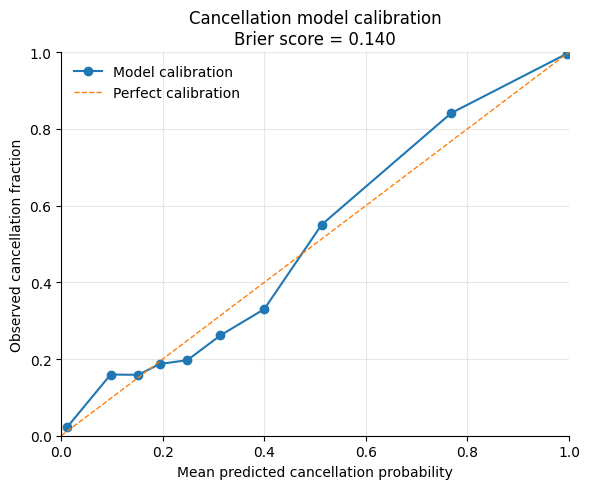

In [19]:
# Fit cancellation model and check calibration
# The model is used to score each booking with p_cancel.

num_features = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "is_repeated_guest",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

cat_features = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
]

feat_cols = num_features + cat_features

model_df = q2_df[feat_cols + ["is_canceled"]].copy()
X = model_df[feat_cols]
y = model_df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

pre = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_features,
        ),
    ]
)

pipe = Pipeline(
    steps=[
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=3000)),
    ]
)

pipe.fit(X_train, y_train)

p_test = pipe.predict_proba(X_test)[:, 1]
y_pred = (p_test >= 0.5).astype(int)

auc = roc_auc_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)
hit_rate = recall_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

model_metrics_q2 = pd.DataFrame(
    [
        {
            "metric": "ROC-AUC",
            "value": round(auc, 3),
            "interpretation": "Ranking quality; useful, but not enough for overbooking.",
        },
        {
            "metric": "Brier score",
            "value": round(brier, 3),
            "interpretation": "Probability accuracy; most relevant for buffer sizing.",
        },
        {
            "metric": "Hit rate at p_cancel >= 0.5",
            "value": round(hit_rate, 3),
            "interpretation": "Share of actual cancellations flagged at the 0.5 threshold.",
        },
        {
            "metric": "MCC at p_cancel >= 0.5",
            "value": round(mcc, 3),
            "interpretation": "Balanced threshold-based classification quality.",
        },
    ]
)

display(model_metrics_q2)

frac_pos, mean_pred = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)

# Score the full book of business
q2_df["p_cancel"] = pipe.predict_proba(q2_df[feat_cols])[:, 1]
q2_df["expected_show"] = 1 - q2_df["p_cancel"]

bookings["p_cancel"] = q2_df["p_cancel"]
bookings["expected_show"] = q2_df["expected_show"]

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    mean_pred,
    frac_pos,
    marker="o",
    linewidth=1.5,
    label="Model calibration",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)

ax.set_title(f"Cancellation model calibration\nBrier score = {brier:.3f}")
ax.set_xlabel("Mean predicted cancellation probability")
ax.set_ylabel("Observed cancellation fraction")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Model Evaluation and Operational Calibration Assessment

The evaluation metrics confirm that the model satisfies the requirements for our capacity planning. 

- The model achieves a high ROC-AUC score of 0.847, verifying an excellent capacity to correctly rank cancellations above non-cancellations. 

- The Brier Score of 0.140 and the accompanying calibration curve provide the most critical validation for the decision problem. The curve shows that across the entire probability spectrum, the model's predictions closely trace the ideal 45-degree line of perfect calibration. This alignment ensures that a predicted probability reliably translates into true expected physical check-ins.

An overconfident model would induce overly aggressive overbooking and escalate costly walk risks, whereas an underconfident model would lead to excessively conservative buffers and unrecovered spoilage revenue.

To transition from individual calibration to sizing the final buffer, we aggregate the predictions across the current book of business. Sizing a robust overbooking buffer requires analyzing two distinct statistical properties of the reservations.

- The Expected Value (p_bar): This represents the baseline cancellation rate, which dictates the deterministic point-buffer ceiling.

- The Joint Variance Structure ($p_{i}$*(1-$p_{i}$)): Since each individual booking follows a Bernoulli trial, its inherent uncertainty is driven by its variance. Aggregating these individual variances allows us to quantify the tail risk of actual check-ins.

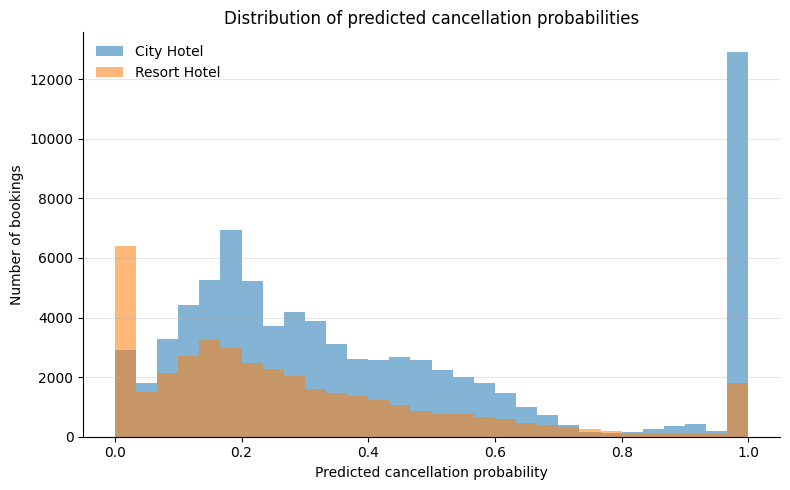

,hotel,bookings,empirical_cancel_rate_pct,p_bar_pct,p_var,expected_var_per_row
0,City Hotel,79330,41.7,41.6,0.097,0.146
1,Resort Hotel,40060,27.8,28.0,0.064,0.137


In [20]:
# Summarise and visualise predicted cancellation probabilities
# p_bar drives the point buffer.
# p_i * (1 - p_i) drives check-in uncertainty and walk-away risk.

fig, ax = plt.subplots(figsize=(8, 5))

for hotel in ["City Hotel", "Resort Hotel"]:
    ax.hist(
        q2_df.loc[q2_df["hotel"] == hotel, "p_cancel"],
        bins=30,
        alpha=0.55,
        label=hotel,
    )

ax.set_title("Distribution of predicted cancellation probabilities")
ax.set_xlabel("Predicted cancellation probability")
ax.set_ylabel("Number of bookings")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

p_summary = (
    q2_df
    .groupby("hotel")
    .agg(
        bookings=("p_cancel", "size"),
        p_bar=("p_cancel", "mean"),
        p_var=("p_cancel", "var"),
        expected_var_per_row=("p_cancel", lambda s: np.mean(s * (1 - s))),
        empirical_cancel_rate=("is_canceled", "mean"),
    )
    .reset_index()
)

for col in ["p_bar", "p_var", "expected_var_per_row", "empirical_cancel_rate"]:
    p_summary[col] = p_summary[col].round(3)

p_summary["p_bar_pct"] = (p_summary["p_bar"] * 100).round(1)
p_summary["empirical_cancel_rate_pct"] = (
    p_summary["empirical_cancel_rate"] * 100
).round(1)

display(
    p_summary[
        [
            "hotel",
            "bookings",
            "empirical_cancel_rate_pct",
            "p_bar_pct",
            "p_var",
            "expected_var_per_row",
        ]
    ]
)

The visualized probability densities and summary statistics highlight distinct risk profiles between the two property types.

The City Hotel exhibits a heavily bimodal distribution. While a large portion of bookings clusters around lower risk tiers, a massive spike occurs close to 1.0. This indicates that the classification pipeline successfully isolates a highly predictable, high-risk segment. 

The Resort Hotel displays a smoother, right-skewed decay, reflecting a more homogeneous leisure segment with intermediate cancellation risks.

The summary statistics confirm the accurate calibration of the framework. For the City Hotel, the mean predicted probability of 41.6% almost perfectly matches the historical empirical cancellation rate of 41.7%. For the Resort Hotel, the model predicts an average risk of 28.0%, directly mirroring the empirical baseline of 27.8%.

While p_bar provides a baseline intuition for the overbooking headroom, Clara cannot size a safe buffer on averages alone. The true operational risk is driven by the dispersion of individual probabilities. A booking with a probability close to 0 or 1 is highly predictable. However, bookings with probabilities around 0.5 carry maximum statistical uncertainty. 

Consequently, two hotels with identical average cancellation rates could require entirely different overbooking buffers depending on their booking mix. A hotel with ambiguous booker behavior creates a highly volatile check-in distribution, escalating the tail risk of costly walk-aways. Our framework successfully captures this by carrying forward both quantities to the final optimization stage. p_bar for the expected point estimate, and the empirical row-level varianceto precisely map out the walk-away risk frontier.

### Managerial Parameters and Risk Appetite Framework

To translate the uncertainty into an operational overbooking buffer, we must formalize Clara’s risk tolerances. This requires balancing the economic trade-off between unrecovered spoilage and spilage. Since the assignment does not specify fixed property sizes, we assume a standardized capacity ($C = 80$) for both hotels. This serves as a necessary baseline anchor to operationalize relative risk parameters and to evaluate the stochastic check-in distribution at the critical capacity limit. 

Crucially, the Resort Hotel is managed more conservatively due to the higher brand damage associated with displacing leisure guests.

In [21]:
# Capacity and managerial risk assumptions

capacity_assumption = {
    "City Hotel": 80,
    "Resort Hotel": 80,
}

# Tolerated number of walked rooms, expressed as a fraction of capacity. This is not the probability of a walk; it is the maximum walk count Clara is willing to exceed only rarely.
walk_count_tolerance_frac = {
    "City Hotel": 0.05,      # up to 4 rooms if c = 80
    "Resort Hotel": 0.025,   # up to 2 rooms if c = 80
}

# Risk appetite: probability of exceeding the tolerated walk count. Resort is stricter because leisure walk-aways create higher brand damage.
risk_appetite = {
    "City Hotel": 0.10,
    "Resort Hotel": 0.05,
}

# Walk cost assumptions for interpretation.

walk_cost_x_adr = {
    "City Hotel": 2.5,
    "Resort Hotel": 4.0,
}

adr_proxy = (
    q2_df[
        (q2_df["is_canceled"] == 0)
        & (q2_df["adr"] > 0)
        & (q2_df["adr"] <= 500)
    ]
    .groupby("hotel")["adr"]
    .median()
)

assumptions_table = pd.DataFrame(
    [
        {
            "hotel": hotel,
            "capacity_assumption": capacity_assumption[hotel],
            "tolerated_walk_count": walk_count_tolerance_frac[hotel] * capacity_assumption[hotel],
            "risk_appetite_pct": risk_appetite[hotel] * 100,
            "walk_cost_x_ADR": walk_cost_x_adr[hotel],
            "ADR_proxy": adr_proxy.loc[hotel],
        }
        for hotel in ["City Hotel", "Resort Hotel"]
    ]
)

assumptions_table["tolerated_walk_count"] = assumptions_table["tolerated_walk_count"].round(1)
assumptions_table["ADR_proxy"] = assumptions_table["ADR_proxy"].round(0)

display(assumptions_table)

,hotel,capacity_assumption,tolerated_walk_count,risk_appetite_pct,walk_cost_x_ADR,ADR_proxy
0,City Hotel,80,4.0,10.0,2.5,100.0
1,Resort Hotel,80,2.0,5.0,4.0,74.0


The parameter table translates the business context into explicit quantitative boundaries. Since room capacity is not directly observed in our data, a standardized baseline of 80 rooms is applied to both properties to convert relative risk metrics into absolute numbers. The resulting boundaries clearly reflect the differing commercial realities of the two hotels. 

The City Hotel is managed with a higher risk appetite of 10% and a tolerance of up to 4.0 walked rooms, which is economically justified by a lower walk cost multiplier and higher local relocation flexibility. 

The Resort Hotel requires a significantly more conservative safeguard, limiting tolerated walks to 2.0 rooms at a strict 5% risk appetite. Because leisure guests have a higher emotional investment in their vacation, a capacity displacement at the Resort causes severe reputational damage and triggers a steep compensation penalty of 4.0 times the ADR.

These four values are assumed managerial inputs rather than estimates from the data, so it is fair to ask how much the final recommendation depends on the exact numbers chosen. Apart from capacity, the two levers that are genuinely free are the risk appetite and the walk tolerance. We therefore recompute the buffer across a grid of both, holding the capacity and the calibrated p_cancel fixed, to see whether the chosen operating point sits on stable ground or on a steep edge.

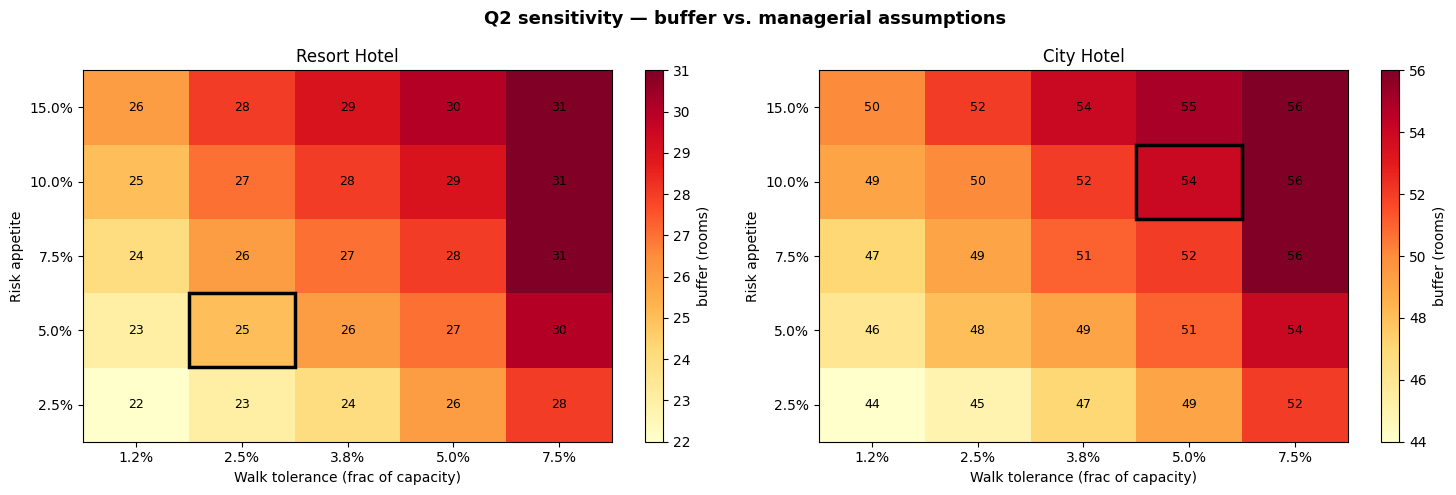

In [22]:
#Q2 sensitivity: how much do the managerial assumptions move the buffer
from math import erf, sqrt, pi, exp

def normal_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def normal_pdf(x):
    return (1 / sqrt(2 * pi)) * exp(-0.5 * x * x)

def expected_walks_normal(mu, sd, capacity):
    if sd <= 0:
        return max(mu - capacity, 0)

    z = (capacity - mu) / sd
    return sd * normal_pdf(z) + (mu - capacity) * (1 - normal_cdf(z))


def buffer_at(hotel, risk, tol_frac):
    h     = bookings[bookings["hotel"] == hotel]
    c     = capacity_assumption[hotel]
    p_bar = h["p_cancel"].mean()
    evar  = float(np.mean(h["p_cancel"] * (1 - h["p_cancel"])))
    n_star  = int(np.ceil(c / (1 - p_bar)))
    ceiling = n_star - c
    tol     = tol_frac * c

    feasible = [0]
    for bb in range(0, ceiling + 21):
        n_sold = c + bb
        mu = n_sold * (1 - p_bar)
        sd = np.sqrt(n_sold * evar)
        prob = 1 - normal_cdf((c + tol - mu) / sd) if sd > 0 else float(mu > c + tol)
        if prob <= risk and bb < ceiling:
            feasible.append(bb)
    return max(feasible)

risk_grid = [0.025, 0.05, 0.075, 0.10, 0.15]
tol_grid  = [0.0125, 0.025, 0.0375, 0.05, 0.075]   # fraction of capacity

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Q2 sensitivity — buffer vs. managerial assumptions",
             fontsize=13, fontweight="bold")

for ax, hotel in zip(axes, ["Resort Hotel", "City Hotel"]):
    grid = np.array([[buffer_at(hotel, r, t) for t in tol_grid] for r in risk_grid])
    im = ax.imshow(grid, cmap="YlOrRd", aspect="auto", origin="lower")
    ax.set_xticks(range(len(tol_grid)))
    ax.set_xticklabels([f"{t:.1%}" for t in tol_grid])
    ax.set_yticks(range(len(risk_grid)))
    ax.set_yticklabels([f"{r:.1%}" for r in risk_grid])
    ax.set_xlabel("Walk tolerance (frac of capacity)")
    ax.set_ylabel("Risk appetite")
    ax.set_title(hotel)
    for i in range(len(risk_grid)):
        for j in range(len(tol_grid)):
            ax.text(j, i, int(grid[i, j]), ha="center", va="center", fontsize=9)
    # mark the chosen operating point
    r_i = risk_grid.index(risk_appetite[hotel])
    t_i = tol_grid.index(walk_count_tolerance_frac[hotel])
    ax.add_patch(plt.Rectangle((t_i - 0.5, r_i - 0.5), 1, 1, fill=False,
                               edgecolor="black", linewidth=2.5))
    fig.colorbar(im, ax=ax, label="buffer (rooms)")

plt.tight_layout(); plt.show()

The surface is a smooth, monotone gradient with no cliffs, and the chosen operating point sits well inside a flat region. Doubling or halving either assumption moves the buffer by only one to two rooms for the Resort and a handful for the City. The recommendation is therefore robust to reasonable changes in managerial preference rather than an artefact of the exact values chosen, and we proceed on the selected parameters with confidence.

In [23]:
# Q2.4b — Prediction-augmented occupancy bridge

q_eff_bridge_rows = []

for hotel in ["City Hotel", "Resort Hotel"]:
    h = q2_df[q2_df["hotel"] == hotel].copy()

    c = capacity_assumption[hotel]
    p_bar = h["p_cancel"].mean()

    expected_checkins_if_capacity_sold = c * (1 - p_bar)
    expected_empty_rooms_without_overbooking = c - expected_checkins_if_capacity_sold

    n_star = int(np.ceil(c / (1 - p_bar)))
    naive_buffer_ceiling = n_star - c
    expected_checkins_at_n_star = n_star * (1 - p_bar)

    q_eff_bridge_rows.append(
        {
            "hotel": hotel,
            "capacity": c,
            "p_bar": p_bar,
            "expected_checkins_if_capacity_sold": expected_checkins_if_capacity_sold,
            "expected_empty_rooms_without_overbooking": expected_empty_rooms_without_overbooking,
            "n_star": n_star,
            "naive_buffer_ceiling": naive_buffer_ceiling,
            "expected_checkins_at_n_star": expected_checkins_at_n_star,
        }
    )

q_eff_bridge = pd.DataFrame(q_eff_bridge_rows)

q_eff_bridge["p_bar_pct"] = (q_eff_bridge["p_bar"] * 100).round(1)

for col in [
    "expected_checkins_if_capacity_sold",
    "expected_empty_rooms_without_overbooking",
    "expected_checkins_at_n_star",
]:
    q_eff_bridge[col] = q_eff_bridge[col].round(1)

display(
    q_eff_bridge[
        [
            "hotel",
            "capacity",
            "p_bar_pct",
            "expected_checkins_if_capacity_sold",
            "expected_empty_rooms_without_overbooking",
            "n_star",
            "naive_buffer_ceiling",
            "expected_checkins_at_n_star",
        ]
    ].reset_index(drop=True)
)

,hotel,capacity,p_bar_pct,expected_checkins_if_capacity_sold,expected_empty_rooms_without_overbooking,n_star,naive_buffer_ceiling,expected_checkins_at_n_star
0,City Hotel,80,41.6,46.7,33.3,137,57,80.0
1,Resort Hotel,80,28.0,57.6,22.4,112,32,80.7


The table also shows why n_star should not be used directly. At n_star, expected check-ins roughly equal capacity, which appears efficient but ignores variance. On nights where fewer guests cancel than predicted, realised check-ins exceed capacity and create walk-aways. The prediction-augmented occupancy logic therefore explains why overbooking is possible, while the risk frontier that follows determines how much overbooking remains acceptable.

### Risk-Constrained Buffer Optimization via Normal Approximation

To find the optimal overbooking buffer, we evaluate every incremental buffer size b on a simulation grid. Since each booking is an independent Bernoulli trial with its own cancellation probability, the total number of check-ins follows a Poisson-Binomial distribution, which we approximate with a Normal distribution via the Central Limit Theorem. We then discard every buffer that breaches Clara's risk appetite and select the largest feasible one, capturing as much revenue potential as possible without crossing the safety boundary.

In [24]:
# Buffer-risk frontier with Poisson-binomial normal approximation

frontier_rows = []
recommendation_rows = []

for hotel in ["City Hotel", "Resort Hotel"]:
    h = q2_df[q2_df["hotel"] == hotel].copy()

    c = capacity_assumption[hotel]
    p_bar = h["p_cancel"].mean()
    p_var = h["p_cancel"].var()
    expected_var_per_row = np.mean(h["p_cancel"] * (1 - h["p_cancel"]))

    n_star = int(np.ceil(c / (1 - p_bar)))
    naive_buffer_ceiling = n_star - c

    tolerated_walk_count = walk_count_tolerance_frac[hotel] * c
    risk_limit = risk_appetite[hotel]

    max_buffer = max(naive_buffer_ceiling + 20, 20)

    for b in range(0, max_buffer + 1):
        n_sold = c + b

        # Approximation:
        # Future book composition resembles the historical hotel-specific mix.
        mu_checkins = n_sold * (1 - p_bar)
        sd_checkins = np.sqrt(n_sold * expected_var_per_row)

        if sd_checkins > 0:
            prob_any_walk = 1 - normal_cdf((c - mu_checkins) / sd_checkins)
            prob_walk_gt_tolerance = 1 - normal_cdf(
                (c + tolerated_walk_count - mu_checkins) / sd_checkins
            )
        else:
            prob_any_walk = float(mu_checkins > c)
            prob_walk_gt_tolerance = float(
                mu_checkins > c + tolerated_walk_count
            )

        exp_walks = expected_walks_normal(mu_checkins, sd_checkins, c)

        frontier_rows.append(
            {
                "hotel": hotel,
                "capacity": c,
                "buffer": b,
                "n_sold": n_sold,
                "p_bar": p_bar,
                "p_var": p_var,
                "expected_var_per_row": expected_var_per_row,
                "n_star": n_star,
                "naive_buffer_ceiling": naive_buffer_ceiling,
                "expected_checkins": mu_checkins,
                "sd_checkins": sd_checkins,
                "expected_walks": exp_walks,
                "prob_any_walk": prob_any_walk,
                "tolerated_walk_count": tolerated_walk_count,
                "prob_walk_gt_tolerance": prob_walk_gt_tolerance,
                "risk_appetite": risk_limit,
                "walk_cost_x_adr": walk_cost_x_adr[hotel],
                "adr_proxy": adr_proxy.loc[hotel],
            }
        )

frontier = pd.DataFrame(frontier_rows)

for hotel, grp in frontier.groupby("hotel"):
    feasible = grp[
        (grp["prob_walk_gt_tolerance"] <= grp["risk_appetite"])
        & (grp["buffer"] < grp["naive_buffer_ceiling"])
    ].copy()

    if feasible.empty:
        chosen = grp[grp["buffer"] == 0].iloc[0]
    else:
        chosen = feasible.sort_values("buffer").iloc[-1]

    recommendation_rows.append(chosen)

q2_recommendation = pd.DataFrame(recommendation_rows)

q2_recommendation_display = q2_recommendation[
    [
        "hotel",
        "capacity",
        "p_bar",
        "p_var",
        "n_star",
        "naive_buffer_ceiling",
        "buffer",
        "n_sold",
        "expected_checkins",
        "sd_checkins",
        "expected_walks",
        "tolerated_walk_count",
        "prob_walk_gt_tolerance",
        "risk_appetite",
        "walk_cost_x_adr",
    ]
].copy()

for col in [
    "p_bar",
    "p_var",
    "expected_checkins",
    "sd_checkins",
    "expected_walks",
    "tolerated_walk_count",
    "prob_walk_gt_tolerance",
    "risk_appetite",
]:
    q2_recommendation_display[col] = q2_recommendation_display[col].round(3)

q2_recommendation_display["p_bar_pct"] = (
    q2_recommendation_display["p_bar"] * 100
).round(1)

q2_recommendation_display["prob_walk_gt_tolerance_pct"] = (
    q2_recommendation_display["prob_walk_gt_tolerance"] * 100
).round(1)

q2_recommendation_display["risk_appetite_pct"] = (
    q2_recommendation_display["risk_appetite"] * 100
).round(1)

q2_recommendation_display = q2_recommendation_display.reset_index(drop=True)

display(
    q2_recommendation_display[
        [
            "hotel",
            "capacity",
            "p_bar_pct",
            "n_star",
            "naive_buffer_ceiling",
            "buffer",
            "n_sold",
            "expected_checkins",
            "sd_checkins",
            "expected_walks",
            "tolerated_walk_count",
            "prob_walk_gt_tolerance_pct",
            "risk_appetite_pct",
            "walk_cost_x_adr",
        ]
    ]
)

,hotel,capacity,p_bar_pct,n_star,naive_buffer_ceiling,buffer,n_sold,expected_checkins,sd_checkins,expected_walks,tolerated_walk_count,prob_walk_gt_tolerance_pct,risk_appetite_pct,walk_cost_x_adr
0,City Hotel,80,41.6,137,57,54,134,78.285,4.426,1.039,4.0,9.8,10.0,2.5
1,Resort Hotel,80,28.0,112,32,25,105,75.636,3.800,0.237,2.0,4.7,5.0,4.0


### Choosing the buffer from the risk frontier

The column naive_buffer_ceiling is deliberately not the final answer. It is the maximum buffer implied by the average cancellation probability. The final buffer is lower because Clara does not only care about expected occupancy. She cares about the probability of excessive walk-aways.

The model treats each accepted booking as a probabilistic check-in. A booking with a high cancellation probability contributes less to expected occupancy than a booking with a low cancellation probability. Aggregating these probabilities gives expected check-ins, while the dispersion of probabilities gives the uncertainty around those check-ins.

The frontier asks, for each possible buffer, how likely it is that actual check-ins exceed capacity by more than the tolerated amount. We select the largest buffer that stays within the hotel-specific risk appetite. 

This is more defensible than choosing the average cancellation count, because walk-aways are created in the tail, on the nights when fewer guests cancel than expected, not at the centre of the distribution. A robust policy must therefore be sized against tail risk rather than expected value.

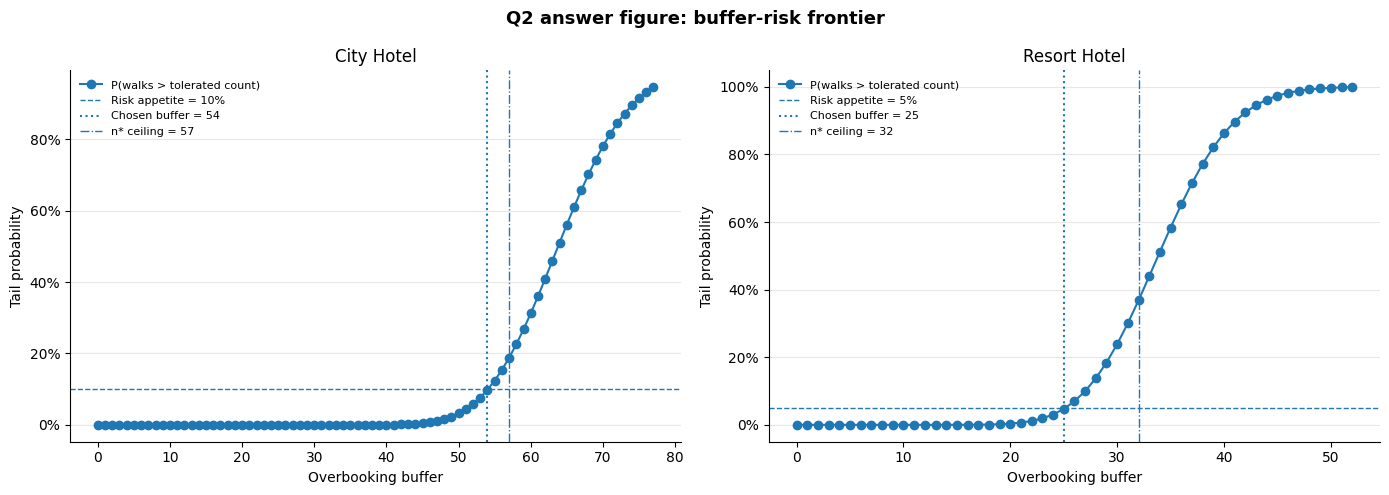

In [25]:
# Q2.6 — Buffer-risk frontier
# This is the main Q2 answer figure.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, hotel in zip(axes, ["City Hotel", "Resort Hotel"]):
    tmp = frontier[frontier["hotel"] == hotel].copy()
    chosen = q2_recommendation[q2_recommendation["hotel"] == hotel].iloc[0]

    ax.plot(
        tmp["buffer"],
        tmp["prob_walk_gt_tolerance"],
        marker="o",
        linewidth=1.5,
        label="P(walks > tolerated count)",
    )

    ax.axhline(
        chosen["risk_appetite"],
        linestyle="--",
        linewidth=1,
        label=f"Risk appetite = {chosen['risk_appetite']:.0%}",
    )

    ax.axvline(
        chosen["buffer"],
        linestyle=":",
        linewidth=1.5,
        label=f"Chosen buffer = {int(chosen['buffer'])}",
    )

    ax.axvline(
        chosen["naive_buffer_ceiling"],
        linestyle="-.",
        linewidth=1,
        label=f"n* ceiling = {int(chosen['naive_buffer_ceiling'])}",
    )

    ax.set_title(hotel)
    ax.set_xlabel("Overbooking buffer")
    ax.set_ylabel("Tail probability")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    "Q2 answer figure: buffer-risk frontier",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

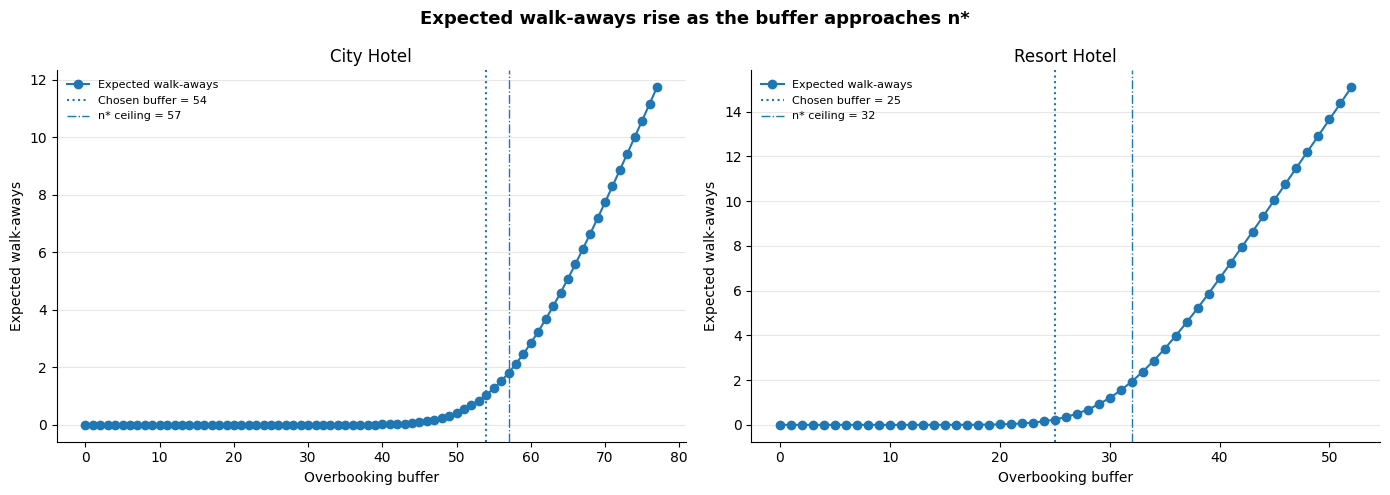

In [26]:
# Q2.7 — Expected walk-aways versus buffer
# This plot shows why the n* ceiling should not be used directly.

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, hotel in zip(axes, ["City Hotel", "Resort Hotel"]):
    tmp = frontier[frontier["hotel"] == hotel].copy()
    chosen = q2_recommendation[q2_recommendation["hotel"] == hotel].iloc[0]

    ax.plot(
        tmp["buffer"],
        tmp["expected_walks"],
        marker="o",
        linewidth=1.5,
        label="Expected walk-aways",
    )

    ax.axvline(
        chosen["buffer"],
        linestyle=":",
        linewidth=1.5,
        label=f"Chosen buffer = {int(chosen['buffer'])}",
    )

    ax.axvline(
        chosen["naive_buffer_ceiling"],
        linestyle="-.",
        linewidth=1,
        label=f"n* ceiling = {int(chosen['naive_buffer_ceiling'])}",
    )

    ax.set_title(hotel)
    ax.set_xlabel("Overbooking buffer")
    ax.set_ylabel("Expected walk-aways")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    "Expected walk-aways rise as the buffer approaches n*",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

The buffer-risk frontier is the main Q2 decision figure. It shows how the probability of exceeding the tolerated walk count changes as Clara accepts more bookings beyond capacity. The chosen buffer is the largest one that still keeps the hotel below its risk appetite, and the n_star ceiling is shown alongside to make clear why the naive point formula should not be used as the recommendation.

The expected-walks plot adds the economic intuition. As the buffer grows, the hotel monetises more expected cancellations, but the expected number of walked guests rises with it. This turns the overbooking decision into a visible trade-off rather than a single-number calculation.

The two hotels should be compared by the shape and position of their frontiers, not only by their final buffer values. A flatter frontier means additional overbooking adds risk slowly, while a steeper one means risk escalates quickly. This is precisely why the policy has to be hotel-specific.

In [27]:
# Final recommendation table

final_q2_table = q2_recommendation[
    [
        "hotel",
        "capacity",
        "p_bar",
        "n_star",
        "naive_buffer_ceiling",
        "buffer",
        "n_sold",
        "expected_checkins",
        "expected_walks",
        "tolerated_walk_count",
        "prob_walk_gt_tolerance",
        "risk_appetite",
    ]
].copy()

final_q2_table["mean_predicted_cancel_pct"] = (
    final_q2_table["p_bar"] * 100
).round(1)

final_q2_table["prob_walk_gt_tolerance_pct"] = (
    final_q2_table["prob_walk_gt_tolerance"] * 100
).round(1)

final_q2_table["risk_appetite_pct"] = (
    final_q2_table["risk_appetite"] * 100
).round(1)

for col in ["expected_checkins", "expected_walks", "tolerated_walk_count"]:
    final_q2_table[col] = final_q2_table[col].round(2)

final_q2_table = final_q2_table[
    [
        "hotel",
        "capacity",
        "mean_predicted_cancel_pct",
        "n_star",
        "naive_buffer_ceiling",
        "buffer",
        "n_sold",
        "expected_checkins",
        "expected_walks",
        "tolerated_walk_count",
        "prob_walk_gt_tolerance_pct",
        "risk_appetite_pct",
    ]
]
final_q2_table = final_q2_table.reset_index(drop=True)
display(final_q2_table)

,hotel,capacity,mean_predicted_cancel_pct,n_star,naive_buffer_ceiling,buffer,n_sold,expected_checkins,expected_walks,tolerated_walk_count,prob_walk_gt_tolerance_pct,risk_appetite_pct
0,City Hotel,80,41.6,137,57,54,134,78.28,1.04,4.0,9.8,10.0
1,Resort Hotel,80,28.0,112,32,25,105,75.64,0.24,2.0,4.7,5.0


### Q2 recommendation

With the stated capacity of 80 rooms per hotel, the buffer-risk frontier yields a recommended buffer of 54 extra bookings for the City Hotel and 25 for the Resort Hotel. Both back off from their naive n_star ceilings, because the final buffer is sized against tail risk rather than the average.

The City Hotel supports the more aggressive buffer. At 54, the probability of exceeding the tolerated walk count is 9.8 %, just inside its 10 % risk appetite. The Resort Hotel is held to 25, where that probability is 4.7 %, inside its stricter 5 % appetite. The difference is intentional. The Resort's steeper frontier and higher walk cost justify a more conservative policy, while the City's flatter frontier and easier recovery support a more aggressive one.

Capacity is not observed in the data, so 80 rooms is a stated assumption that scales every figure proportionally. Cancellations are treated as conditionally independent, which is reasonable for transient bookings but understates tail risk for block bookings where one decision cancels many rooms. And is_canceled may not fully capture day-of-arrival no-shows. The buffer should therefore be monitored and recalibrated once live high-season behaviour is observed, and treated as a controlled maximum rather than a daily target.

This sets up the rest of the analysis. Q2 provides the transparent static baseline, Q3 re-cuts it by season, and Q4 updates it dynamically as live bookings and cancellations arrive.

## §Q3 · Seasonally Update Your Rules

Demand patterns shift across the year. Clara wants Q1's advance sale limits and Q2's overbooking buffers to **adapt to seasonality**.

- Using appropriate aggregates from past years, identify periods of stronger or weaker demand **for each hotel**.
- Provide **updated rules** (per hotel Ã— period) and justify each adjustment with observed patterns.

In Q1 we derived one advance-sale limit per hotel and Q2 we gave one overbooking buffer per hotel. Both are averages over the whole year. A static number that is the expected value of the curve. 

In Q3 we update this static number in respect to different seasons. We cut each hotel's year into peak / shoulder / low seasons based on the data, then re-run the exact same Q1 and Q2 logic on each season's months. 



### Defining the season calendar from ADR

Before we can adapt any rule we need to define different seasons, using the same criterion Q1 already chose. In Q1 we explicitly defined high season by ADR elevation, not arrival volume. For the Resort, volume and price point in opposite direction, so a volume-based definition would misidentify the economically relevant peak. 

Q3 formalises that decision. Where Q1 identified high season by visual inspection of the ADR time series, Q3 derives season labels from an explicit decision rule. We aggregate median canonical ADR (A/BB/2, realised) by hotel × arrival-month, pooled across years, and compare each month's ADR against that hotel's overall median monthly ADR. A month is labelled peak if its ADR is ≥ 1.15× the hotel median, low if ≤ 0.85×, and shoulder otherwise. The 1.15/0.85 thresholds are a deliberate choice and are shaded on the demand calendar so the cut-off is visible and defensible.

Season labels are assigned based on arrival date, not booking date, because every capacity decision, advance limit and overbooking buffer, attaches to the night being sold, not the day it was booked. We still plot realised volume alongside ADR for context, but the bands key off ADR, exactly as in Q1. This one ADR-based season calendar per hotel then drives both the advance limit and the overbooking buffer. The buffer's seasonal mover is still the cancellation rate within these bands.

Resort Hotel : {'peak': [6, 7, 8, 9], 'shoulder': [2, 3, 4, 5, 10], 'low': [1, 11, 12]}
City Hotel : {'peak': [5], 'shoulder': [1, 2, 3, 4, 6, 7, 8, 9, 10, 11], 'low': [12]}


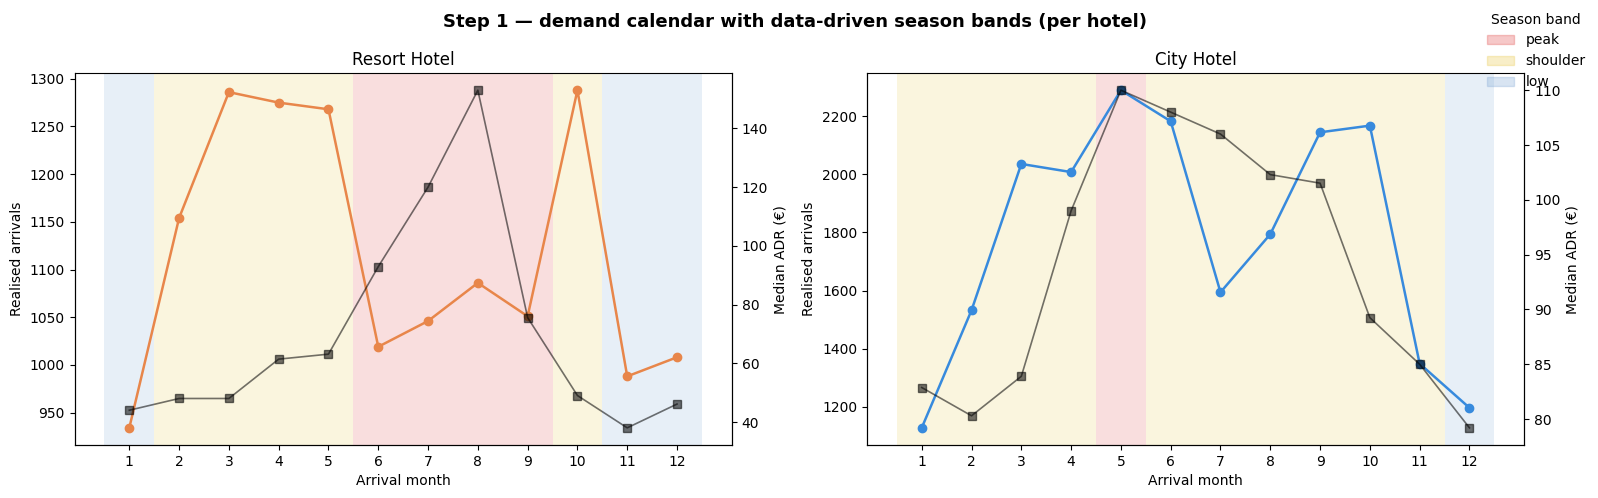

In [28]:
#data driven season bands per hotel
c_adr = canon.copy()
c_adr["month"] = c_adr["arrival_date"].dt.month     #monat aus arrival date holen
adr_m = c_adr.groupby(["hotel", "month"])["adr"].median()    # ADR per hotel x month

# Realised volume kept only for the context line on the plot below.
r = realised.copy()
r["year"] = r["arrival_date"].dt.year
r["month"] = r["arrival_date"].dt.month
vol = (
    r.groupby(["hotel", "year", "month"])       #volume für plot als reference 
     .size()
     .groupby(["hotel", "month"])
     .mean()                          # Mittelwert über die Jahre
     .round()
     .astype(int)
)

def band_of(v, med):               #decision rule: v = adr eines monats; med = hotel wide median
    if v >= 1.15 * med:
        return "peak"
    if v <= 0.85 * med:
        return "low"
    return "shoulder"

season_months = {}
for h in hotels:
    s = adr_m.loc[h]                       #s = 12 monatliche median adrs
    med = s.median()                        #med = median dieser 12 werte
    labels = {m: band_of(v, med) for m, v in s.items()} #jedem monat ein band zuweisen
    season_months[h] = {
        sea: sorted(m for m, lab in labels.items() if lab == sea)   #ergebnis invertieren: pro band eine Liste der zugehörigen Monate
        for sea in ["peak", "shoulder", "low"]
    }

for h in hotels:
    print(h, ":", season_months[h])

#banded demand calendar
band_color = {"peak": "#E24B4A", "shoulder": "#E8C84A", "low": "#7FA7D4"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
fig.suptitle("Step 1 — demand calendar with data-driven season bands (per hotel)",
             fontsize=13, fontweight="bold")

for ax, h in zip(axes, hotels):
    v, a = vol.loc[h], adr_m.loc[h]
    for sea, months in season_months[h].items():
        for m in months:
            ax.axvspan(m - 0.5, m + 0.5, color=band_color[sea], alpha=0.18, lw=0)
    ax.plot(v.index, v.values, marker="o", color=hotel_colors[h], linewidth=1.8,
            label="Realised arrivals")
    ax2 = ax.twinx()
    ax2.plot(a.index, a.values, marker="s", color="black", alpha=0.55,
             linewidth=1.2, label="Median canonical ADR")
    ax.set_title(h)
    ax.set_xlabel("Arrival month")
    ax.set_xticks(range(1, 13))
    ax.set_ylabel("Realised arrivals")
    ax2.set_ylabel("Median ADR (€)")
    ax.spines[["top"]].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=band_color[s], alpha=0.3) for s in band_color]
fig.legend(handles, list(band_color.keys()), title="Season band",
           loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

The two hotels have genuinely different seasonal shapes, and that difference is itself a finding.

As established in Q1, the Resort's ADR and volume signals point in opposite directions. The data-driven rule (≥ 1.15× / ≤ 0.85× hotel median) reproduces Q1's summer peak and adds one additional refinement. September qualifies as peak under the ADR criterion, with its median canonical ADR still clearing the threshold. The Resort's season calendar is therefore June–September (peak), February–May and October (shoulder), and January, November, December (low).

The City Hotel tells the opposite story. Its ADR is nearly flat year-round, leaving almost no month far enough from the hotel median to trigger a band change. The rule produces a single peak month (May) and a single low (December), with everything else in shoulder. This flatness is itself the finding. It confirms Q1's decision to run the City on the full year without seasonal restriction, and it means that a seasonal advance-limit or buffer schedule adds little value for the City Hotel. We carry the structure through the following steps for completeness, but the near-identical values across bands are expected.

This contrast, Resort sharply peaked, City structurally flat, is why a single shared season calendar would misprice one of the two hotels.

### Stability Verification of Seasonal Bands

A season label is only a trustworthy forward rule if the underlying monthly pattern repeats. A peak confined to a single year is an outlier, not a seasonal regularity. We therefore overlay realised arrival volume by month, drawing one line per year per hotel, to confirm that the shapes identified in Step 1 are consistent across the observation window.

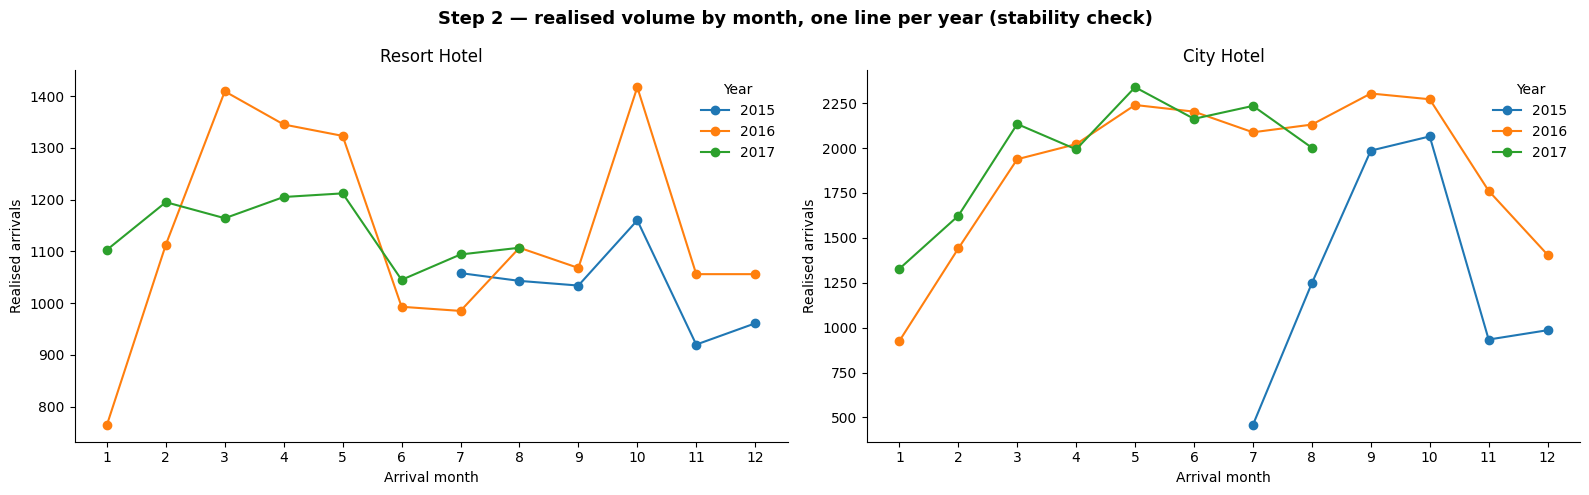

In [29]:
#year-over-year stability overlay 
r["year"] = r["arrival_date"].dt.year   #jahr aus arrival date extrahieren
vy = r.groupby(["hotel", "year", "month"]).size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
fig.suptitle("Step 2 — realised volume by month, one line per year (stability check)",
             fontsize=13, fontweight="bold")
for ax, h in zip(axes, hotels): 
    for yr in sorted(r["year"].unique()):   #über alle jahre iterieren
        try:
            s = vy.loc[(h, yr)] #try-error block als absicherung 
        except KeyError:
            continue
        ax.plot(s.index, s.values, marker="o", linewidth=1.5, label=str(yr))
    ax.set_title(h)
    ax.set_xlabel("Arrival month")
    ax.set_xticks(range(1, 13))
    ax.set_ylabel("Realised arrivals")
    ax.legend(frameon=False, title="Year")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The summer Resort peak and the City peak reappear in every year that covers those months, so the defined bands are a stable forward rule rather than a one-year artefact. The partial-coverage years sit lower in absolute terms but preserve the same monthly shape, which is the relevant criterion. The season definitions are safe to attach pricing and capacity rules to.

### Re-cutting Seasonal advance-sale limits

We re-run Q1's logic unchanged, once per season. For each hotel × season we (a) sweep the early-vs-late ADR gap on the season's canonical rows using the same gap_sweep, (b) pick a lead-time cut with the same criterion as in Q1 (Resort uses max_gap, City uses plateau) and (c) apply the same Littlewood protection rule.

In [30]:
#re-run Q1's cut + Littlewood logic per season 
cut_criterion = {"Resort Hotel": "max_gap", "City Hotel": "plateau"}  # same as Q1

def protection_for(hotel, months, cut):
    #Q1's Littlewood protection level, restricted to a season's months.
    pop = hotel_subset(hotel, months)            # realisiertes volumen, gefiltert auf jeweilige monate
    d   = canon_subset(hotel, months)            # canonical adr gefiltert auf jeweilige monate
    p_L = d.loc[d["lead_time"] >= cut, "adr"].median()   # early / advance fare
    p_H = d.loc[d["lead_time"] <  cut, "adr"].median()   # late / spot fare
    ratio = p_L / p_H if p_H else 1.0   #else falls durch 0 geteilt wird
    late = pop[pop["lead_time"] < cut].groupby("arrival_date").size()   #späte nachfrage berechnen
    #littlewood block
    y = 0   #startwert: 0 schützen 
    if len(late):   #nur weitermachen wenn spätbuchung überhaupt vorhanden
        for x in range(1, int(late.max()) + 1): #iterieren bis max. Spätbuchungszahl pro Anreisedatum
            if (late >= x).mean() >= ratio:
                y = x
            else:
                break
    return y, ratio, p_L, p_H, len(late)

def cut_for(hotel, months):
    sub = canon_subset(hotel, months)
    sw = gap_sweep(sub, min_n=min_n[hotel]) #gap sweep aus Q1

    # Fallback für zu dünne Segmente:
    if sw.empty:
        sw = gap_sweep(sub, min_n=1)          # Threshold lockern

    if sw.empty:                              #wenn immer noch leer:
        if len(sub):
            return int(round(sub["lead_time"].median()))   # eigener Median als Cut
        return int(round(np.median(cut_range)))            # letzter Ausweg: globalen median nehmen

    pos = sw[sw["gap"] > 0]
    cand = select_candidates(pos if not pos.empty else sw)  #selbe cut kriterien wie Q1
    return cand[cut_criterion[hotel]]

The functions are deliberately thin wrappers around the same gap_sweep, select_candidates, and Littlewood logic from Q1. The only input that changes is the month set restricted to the respective season. Reusing the identical method per season rather than re-deriving it guarantees that the seasonal limits are directly comparable to the annual Q1 number and to each other.

### Re-cutting Seasonal overbooking buffers

The buffer does not automatically rise in peak. It follows the cancellation rate, which varies by month and drives the Poisson-binomial-normal frontier from Q2. We re-run that frontier once per season, using the calibrated per-booking p_cancel from the Q2 pipeline. The raw empirical cancellation rate is plotted alongside as a sanity check.

One deliberate seasonal refinement is applied to the walk tolerance. Walking a guest in peak carries higher brand cost than in low season, so we scale the tolerated walk count via season_tol_scale: tighter in peak, looser in low. The seasonal buffer therefore responds to two signals simultaneously. The cancellation rate, which is mechanical, and the walk-cost tolerance, which is a managerial input.

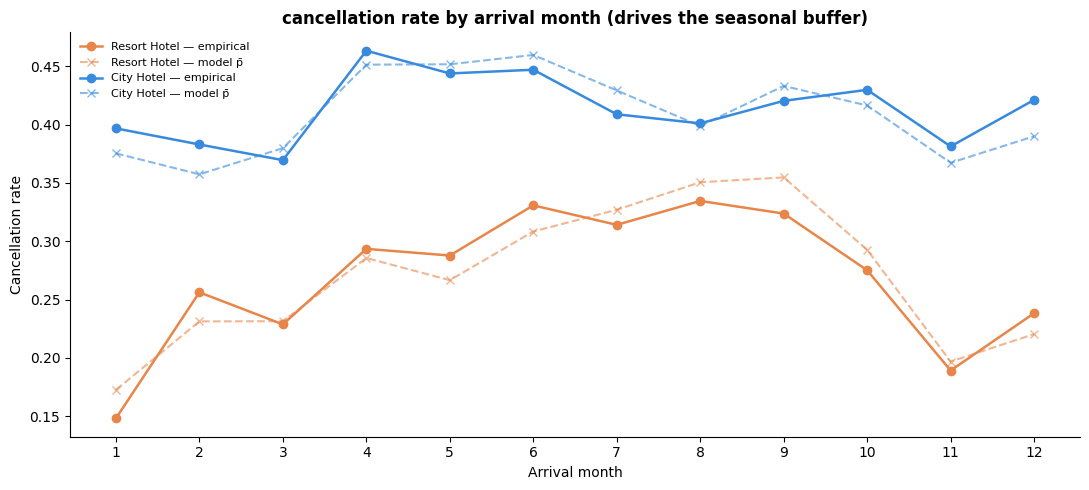

In [31]:
#cancellation rate by month, per hotel - both lines as sanity check
b = bookings.copy()
b["month"] = b["arrival_date"].dt.month
cr = b.groupby(["hotel", "month"])["is_canceled"].mean()    # empirical
pc = b.groupby(["hotel", "month"])["p_cancel"].mean()       # model p_bar

fig, ax = plt.subplots(figsize=(11, 5))
for h in hotels:
    ax.plot(cr.loc[h].index, cr.loc[h].values, marker="o",
            color=hotel_colors[h], linewidth=1.8, label=f"{h} — empirical")
    ax.plot(pc.loc[h].index, pc.loc[h].values, marker="x", linestyle="--",
            color=hotel_colors[h], alpha=0.6, label=f"{h} — model p̄")
ax.set_title("cancellation rate by arrival month (drives the seasonal buffer)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Arrival month")
ax.set_xticks(range(1, 13))
ax.set_ylabel("Cancellation rate")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
# Q2 buffer frontier, restricted to a season
# Walk tolerance is tighter in peak (a peak walk-away costs more brand-wise),
# looser in low season. This is a managerial choice we justify, not data.
season_tol_scale = {"peak": 0.75, "shoulder": 1.0, "low": 1.25} #toleranz wird skaliert

def buffer_for(hotel, months, tol_scale=1.0):
    h = bookings[(bookings["hotel"] == hotel)
                 & (bookings["arrival_date"].dt.month.isin(months))]
    c = capacity_assumption[hotel]
    p_bar = h["p_cancel"].mean()    #mittlere stonierungswahrscheinlichkeit der season 
    evar  = float(np.mean(h["p_cancel"] * (1 - h["p_cancel"])))   # erwartete varianz pro buchung 
    n_star  = int(np.ceil(c / (1 - p_bar))) #natürliche obergrenze 
    ceiling = n_star - c    #maximaler buffer
    tol  = walk_count_tolerance_frac[hotel] * c * tol_scale #absolute anzahl an walks die noch akzeptiert werden 
    risk = risk_appetite[hotel]

    feasible = []
    for bb in range(0, ceiling + 21):   #für jeden Buffer (+kleinen Sicherheitspuffer)
        n_sold = c + bb #anzahl an verkauften Zimmern
        mu = n_sold * (1 - p_bar)   #erwartete Ankünfte
        sd = np.sqrt(n_sold * evar) #standardabweichung der Ankünfte
        if sd > 0:
            prob_walk_gt_tol = 1 - normal_cdf((c + tol - mu) / sd)  #wie wahrscheinlich ist es das zu viele Gäste kommen
        else:
            prob_walk_gt_tol = float(mu > c + tol)  #fallback falls sd = 0
        if prob_walk_gt_tol <= risk and bb < ceiling:
            feasible.append(bb)

    buf = max(feasible) if feasible else 0      #den größten noch feasiblen buffer nehmen
    return {"buffer": buf, "p_bar": p_bar, "n_star": n_star,
            "ceiling": ceiling, "n_sold": c + buf, "tol": tol}

The cancellation rate chart is the key input to the seasonal buffer. For the Resort, the summer cancellation rate (~33%) is roughly double the winter rate (~15–19%), which mechanically justifies a larger peak buffer. The tighter peak walk tolerance partially offsets this, so the net peak buffer rises only modestly. For the City Hotel, the cancellation rate is high and flat across all months (~40–46%), producing a large but largely uniform buffer with little seasonal variation to exploit.

The model p̄ tracks the empirical rate closely across both hotels, which validates the use of p_cancel as a calibrated probability rather than a ranking. The buffer and the advance limit respond to different underlying signals. The buffer is driven by cancellation rate and walk-cost tolerance, the advance limit by the early-vs-late price gap. As a result, the two rules do not follow the same seasonal pattern.

### The seasonal rule set and the City–Resort contrast

Finally, we assemble the full seasonal rule set. For each hotel × season, we record the months, demand level, early-vs-late ADR gap, cancellation rate p̄, advance-sale limit, and overbooking buffer. This table is the Q3 deliverable. The static Q1/Q2 numbers, now indexed by season and plotted as grouped bars for direct comparison across hotels.

,hotel,season,months,demand_index,cut_d,adr_gap,p_L,p_H,protection,advance_limit,p_bar_pct,buffer,n_sold
0,Resort Hotel,peak,"[6, 7, 8, 9]",0.31,192,50.3,74.7,125.0,24,56,33.6,32,112
1,Resort Hotel,shoulder,"[2, 3, 4, 5, 10]",0.47,3,8.0,50.0,58.0,3,77,26.3,23,103
2,Resort Hotel,low,"[1, 11, 12]",0.22,6,10.2,37.8,48.0,7,73,19.8,16,96
3,City Hotel,peak,[5],0.11,2,29.0,110.0,139.0,2,78,45.2,60,140
4,City Hotel,shoulder,"[1, 2, 3, 4, 6, 7, 8, 9, 10, 11]",0.84,3,13.6,91.4,105.0,2,78,41.3,53,133
5,City Hotel,low,[12],0.06,6,14.9,75.0,89.9,4,76,39.0,50,130


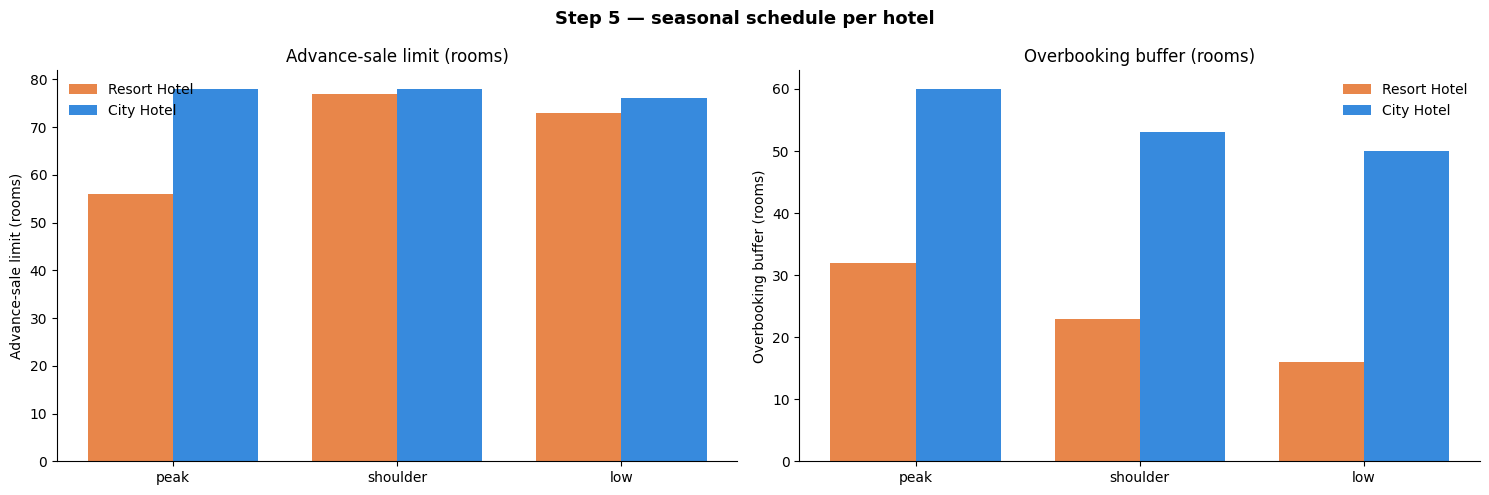

In [33]:
# assemble the seasonal rules table
order = ["peak", "shoulder", "low"]
q3_rows = []
for h in hotels:        #für jedes hotel
    cap = capacity_assumption[h]    
    for sea in order:
        months = season_months[h][sea]  #season holen
        if not months:  
            continue
        #funktionen aufrufen
        cut = cut_for(h, months)        #lead time cut pro season
        y, ratio, p_L, p_H, n_nights = protection_for(h, months, cut)      #littlewood 
        buf = buffer_for(h, months, season_tol_scale[sea])  #overbooking buffer
        q3_rows.append({
            "hotel": h,
            "season": sea,
            "months": months,
            "demand_index": round(vol.loc[h, months].sum() / vol.loc[h].sum(), 2),  #anteil der season am Jahresvolumen
            "cut_d": cut,
            "adr_gap": round((p_H - p_L), 1),   
            "p_L": round(p_L, 1),
            "p_H": round(p_H, 1),
            "protection": y,
            "advance_limit": cap - y,   # wie viele zimmer dürfen früh verkauft werden
            "p_bar_pct": round(buf["p_bar"] * 100, 1),  #stonierungsrate
            "buffer": buf["buffer"],
            "n_sold": buf["n_sold"],
        })

q3_rules = pd.DataFrame(q3_rows)
display(q3_rules)

#grouped-bar schedule
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Step 5 — seasonal schedule per hotel", fontsize=13, fontweight="bold")
for ax, metric, title in zip(
    axes, ["advance_limit", "buffer"],
    ["Advance-sale limit (rooms)", "Overbooking buffer (rooms)"]
):
    x = np.arange(len(order))
    width = 0.38
    for i, h in enumerate(hotels):
        vals = []
        for s in order:
            sub = q3_rules[(q3_rules.hotel == h) & (q3_rules.season == s)][metric].values
            vals.append(sub[0] if len(sub) else 0)
        ax.bar(x + (i - 0.5) * width, vals, width, label=h, color=hotel_colors[h])
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


For the Resort, the advance-sale limit is tightest in the June–September peak, where the ADR gap is widest and late high-fare demand is strong enough to justify holding back rooms (peak limit 56 vs. 73–77 in shoulder and low). Outside peak, the gap collapses and late demand thins, so the limit loosens to lock in volume early. The overbooking buffer follows the cancellation rate. Largest in peak (~32 rooms) and declining toward low season (~16), partially offset by the tighter peak walk tolerance.

For the City Hotel, both schedules are near-flat. With only one peak month (May) and one low month (December), the ADR gap and cancellation rate barely shift across seasons, leaving the advance limit virtually unchanged (~76–78 rooms) and the buffer declining only mildly (~60 to ~50). The seasonal adjustment here is a nudge rather than a regime change.

### Q3 recommendation 

The static Q1/Q2 numbers should not be applied uniformly across the year. Re-cutting them by ADR-defined season produces one season calendar per hotel that drives both the advance-sale limit and the overbooking buffer, and the two hotels respond very differently.

For the Resort, seasonality is real and worth acting on. The advance limit tightens to 56 rooms in the June–September peak, where pricing power is highest, and loosens to 73–77 outside it. The buffer moves with the cancellation rate, from about 32 rooms in peak down to 16 in low. For the City Hotel, the flat ADR profile leaves every schedule near-constant, so the seasonal adjustment is a nudge rather than a regime change.

The practical message is that the value of seasonal differentiation is itself hotel-specific. The Resort should run the full seasonal rule set, for the City Hotel a single annual rule would lose almost nothing. This finding carries directly into Q4, where we apply the dynamic policy to the Resort only, precisely because the City's flat profile means live adaptation cannot earn back its added complexity.

## §Q4 · Operate on Live Booking Data

Simulate a realistic decision environment for Viador:

1. **Pick a stay date** and extract its booking strip â€” every booking with any lead time that ultimately stays on that night.
2. Replay it as a **time-ordered stream** of requests (by lead time).
3. Implement an **adaptive control strategy** that:
    - Makes daily decisions based on current capacity and expected high-/low-fare arrivals.
    - **Dynamically updates** protection limits or overbooking thresholds as bookings (and cancellations) arrive.
    - **Integrates at least one trained model** (cancellation probability, ADR forecast, â€¦) to improve decisions.

Report realised revenue, spillage, and walk-aways; compare against the static Q1 + Q2 baseline. A good recommendation is *transparent, robust to noise, and clearly communicated*.

### The static rule as baseline 

We first define the static policy that serves as the benchmark. The static policy uses the overbooking buffer from and the seasonal protection levels. In this sense, cancellation risk and seasonality are already reflected in the parameters by the rule.

However, during the booking-strip simulation, the static policy does not weight each individual request by its cancellation probability. Each accepted booking reduces the remaining booking limit by one full room. The cancellaation probabilities are therefore not updated or applied at the request level, but enter the static policy only through the fixed parameters estimated beforehand. 

This makes tge policy a risk-informed benchmark. The dynamic policy extends this setup by updating the decision state during the strip using cancellation-adjusted occupancy and remaining high-fare demand predictions. 

In [34]:
def run_static(strip, cap, protect, fare_cut, buffer = 0):
    rooms = cap + buffer
    rev = 0.0
    hi = lo = rej_hi = rej_lo = 0
    accepted = []
    for _, r in strip.sort_values("booking_date").iterrows():
        high = r["adr"] >= fare_cut
        if high and rooms > 0:
            rooms -= 1; hi += 1; rev += r["adr"]; accepted.append(r)
        elif (not high) and rooms > protect:
            rooms -= 1; lo += 1; rev += r["adr"]; accepted.append(r)
        else:
            rej_hi += int(high); rej_lo += int(not high)
    return accepted, dict(revenue=rev, high=hi, low=lo,
                          spillage=rej_hi, spoilage=max(rooms, 0))

### Picking the night and setting up the parameters

We choose 6 June 2017 as the stay date, a Resort peak night, where the seasonal ADR elevation is strongest and the payoff from reacting to a night's actual booking pace is therefore largest. As before, we fix the room type to the canonical type A so that capacity, protection, and the fare cut all refer to one homogeneous inventory pool.

We carry three parameters over from Q3 for the stay night's season. The Littlewood protection level and the overbooking buffer come directly from q3 rules. The fare cut, here, plays a different role. We replay individual booking offers and decide whether to accept each one, so we need a price threshold that classifies an incoming request as high or low fare. That cut needs a short derivation of its own, which we cover next.

In [35]:
cap        = capacity_assumption["Resort Hotel"]   # 80, consistent with Q2/Q3
hotel_str  = "Resort Hotel"
room_type  = "A"                                    # canonical, dominant room type

def extract_strip(bk, stay_date, hotel, room_type):
    nights = bk["stays_in_weekend_nights"] + bk["stays_in_week_nights"]
    covers = (
        (bk["arrival_date"] <= stay_date)
        & (stay_date < bk["arrival_date"] + pd.to_timedelta(nights, unit="D"))
        & (bk["hotel"] == hotel)
        & (bk["reserved_room_type"] == room_type)
    )
    return bk.loc[covers].sort_values("booking_date").reset_index(drop=True)

def season_of(date, hotel):
    m = pd.Timestamp(date).month
    for sea, months in season_months[hotel].items():
        if m in months:
            return sea
    return "shoulder"

fare_cut_by, buffer_by = {}, {}
for h in hotels:
    for sea in ["peak", "shoulder", "low"]:
        months = season_months[h][sea]
        sub = realised[(realised["hotel"] == h)
                       & (realised["reserved_room_type"] == room_type)
                       & (realised["arrival_date"].dt.month.isin(months))]
        fare_cut_by[(h, sea)] = float(sub["adr"].median())
        buffer_by[(h, sea)]   = int(q3_rules[(q3_rules.hotel == h)
                                    & (q3_rules.season == sea)].iloc[0]["buffer"])

def q3_params_for(season, hotel):
    protect = int(q3_rules[(q3_rules.hotel == hotel)
                  & (q3_rules.season == season)].iloc[0]["protection"])
    return protect, fare_cut_by[(hotel, season)], buffer_by[(hotel, season)]

stay_date     = pd.to_datetime("2017-06-17")          # a Resort peak night
season_label  = season_of(stay_date, hotel_str)
# fare_cut is the season-median ADR; the choice is justified against the distribution in the next cell. Computed here so all Q3 params load together.
base_protect, fare_cut, season_buffer = q3_params_for(season_label, hotel_str)

#### Choosing the fare cut

There are a few possible fare cut candidates. One is to reuse the Q3 midpoint of p_L and p_H. Another is to mirror the Q3 gap-sweep on the price axis and cut at the widest gap in the ADR distribution, though that only yields a stable split if the distribution is genuinely bimodal. A third is the season median ADR, which splits the pool into two equal classes by construction. Which of these is sensible depends on the shape of the distribution, so we inspect it before committing.

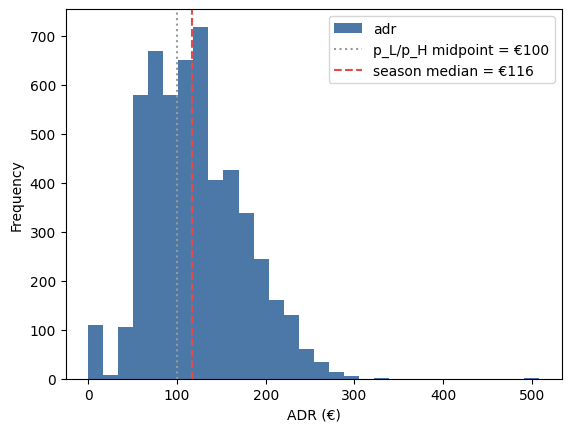

In [36]:
season_pool = realised[
    (realised["hotel"] == hotel_str)
    & (realised["reserved_room_type"] == room_type)
    & (realised["arrival_date"].dt.month.isin(season_months[hotel_str][season_label]))
]
sea_row  = q3_rules[(q3_rules.hotel == hotel_str) & (q3_rules.season == season_label)].iloc[0]
midpoint = (sea_row["p_L"] + sea_row["p_H"]) / 2

ax = season_pool["adr"].plot.hist(bins=30, color="#4C78A8")
ax.axvline(midpoint, color="#999", linestyle=":", label=f"p_L/p_H midpoint = €{midpoint:.0f}")
ax.axvline(fare_cut, color="#E24B4A", linestyle="--", label=f"season median = €{fare_cut:.0f}")
ax.set_xlabel("ADR (€)"); ax.set_ylabel("Frequency"); ax.legend()

The season-pool ADR distribution is unimodal, with a dominant mass between roughly €50 and €200 and a long upper tail. This rules out the gap-sweep, which has no genuine point to lock onto and would cut on noise in the thin tails. The p_L/p_H midpoint and the season median both fall inside the main mass and would behave similarly here. We adopt the season median, because it splits the pool into two equal classes by construction and does not depend on the lead-time cut that produced p_L and p_H, keeping the fare threshold a property of price alone.

In [37]:
strip = extract_strip(bookings, stay_date, hotel_str, room_type)
strip["p_cancel"]      = pipe.predict_proba(strip[feat_cols])[:, 1]
strip["expected_show"] = 1 - strip["p_cancel"]

print(f"{stay_date.date()} | season={season_label} | requests={len(strip)} | "
      f"high-fare share={ (strip['adr'] >= fare_cut).mean():.0%} | "
      f"fare_cut=€{fare_cut:.0f} | base_protect={base_protect} | "
      f"Q2 buffer={season_buffer}")
strip[["booking_date", "lead_time", "adr", "p_cancel", "is_canceled"]].head()

2017-06-17 | season=peak | requests=147 | high-fare share=29% | fare_cut=€116 | base_protect=24 | Q2 buffer=32


,booking_date,lead_time,adr,p_cancel,is_canceled
0,2016-06-14,368,200.00,0.691889,1
1,2016-06-14,368,200.00,0.691889,1
2,2016-06-22,347,86.70,0.309272,0
3,2016-06-22,348,86.70,0.092307,0
4,2016-06-22,348,86.13,0.092087,0


The chosen Resort peak night is heavily requested, carrying far more requests than the estimated capacity of 80 rooms, and the season-median fare cut splits them into a genuine high- and low-fare mix. This makes it a meaningful test bed. Capacity is under real pressure, the fare composition has to be actively managed, and there is enough cancellation risk for the expected-show logic to matter.

### Preparing the two models

#### Reusing the Q2 cancellation model

No new training is needed. The Q2 pipeline already converts each request into a calibrated p_cancel, and hence an expected_show = 1 − $p_{cancel}$. This feeds the numerator of the Booking Pressure calculation. It lets us track expected occupancy rather than raw booking count, which is exactly what makes controlled overbooking possible.

In [38]:
# already attached in Step 1; shown here as the explicit Q2 - Q4 hand-off
strip[["adr", "p_cancel", "expected_show"]].describe().round(3)

,adr,p_cancel,expected_show
count,147.000,147.000,147.000
mean,100.363,0.321,0.679
std,39.767,0.211,0.211
min,0.000,0.000,0.233
25%,80.100,0.153,0.494
50%,86.700,0.309,0.691
75%,122.000,0.506,0.847
max,200.000,0.767,1.000


Each accepted request contributes only its show probability to occupancy. A request that is 30 % likely to cancel counts as 0.7 of a room rather than a full one. Summed over all accepted requests, this gives the cancellation-adjusted occupancy $q_{eff}$ that forms the numerator of Booking Pressure.

#### Training the demand regressor

The dynamic policy needs to know how many high-fare requests are still to come before arrival, which is the denominator of Booking Pressure. We frame this in terms of distance to arrival rather than calendar time, so a calendar-based ARIMA or ETS model would be the wrong tool. For every historical Resort room-A night and every point in its booking sequence, we record the state at that moment and the true number of high-fare requests that arrived afterwards.

demand regressor — RMSE=13.53 remaining high-fare requests | R²=0.717 | target std=26.64 | n=28,495


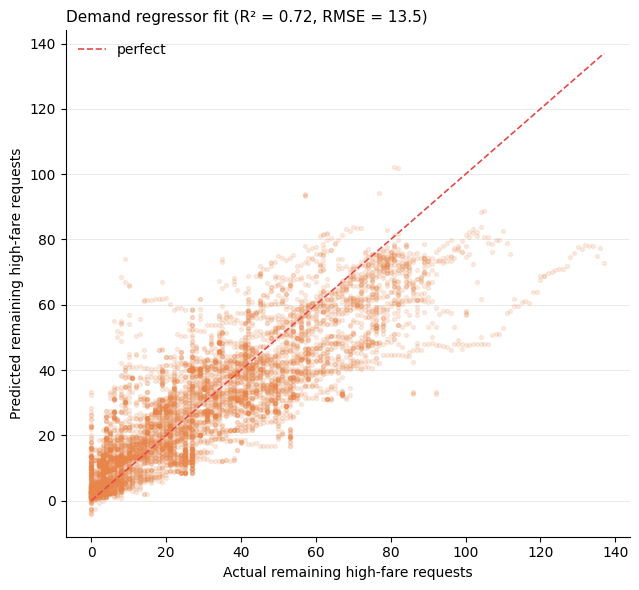

In [39]:
# Build (night x time-step) training rows on a fast, pre-filtered frame.
resort_A = bookings[(bookings["hotel"] == hotel_str)
                    & (bookings["reserved_room_type"] == room_type)]

last_safe    = bookings["arrival_date"].max() - pd.Timedelta(days=30)
train_nights = pd.date_range("2015-07-01", last_safe, freq="3D")

eval_nights  = pd.to_datetime(["2017-07-10", "2017-06-17"])
train_nights = train_nights[~train_nights.isin(eval_nights)]

rows = []
for night in train_nights:
    s = extract_strip(resort_A, night, hotel_str, room_type)
    if len(s) < 5:
        continue
    sea = season_of(night, hotel_str)
    _, fc, _ = q3_params_for(sea, hotel_str)
    dta     = (night - s["booking_date"]).dt.days.to_numpy()
    is_high = (s["adr"] >= fc).astype(int).to_numpy()
    cum_high, total_high = np.cumsum(is_high), int(is_high.sum())
    for t in range(len(s)):
        rows.append({
            "night":            night,           
            "days_to_arrival":  int(dta[t]),
            "bookings_so_far":  t + 1,
            "high_so_far":      int(cum_high[t]),
            "season":           sea,
            "y_remaining_high": int(total_high - cum_high[t]),
        })
train = pd.DataFrame(rows)

all_nights = train["night"].unique()
train_n, test_n = train_test_split(all_nights, test_size=0.25, random_state=42)

is_test = train["night"].isin(test_n)
feat_cols_d = ["days_to_arrival", "bookings_so_far", "high_so_far", "season"]

X_train = train.loc[~is_test, feat_cols_d]
X_test  = train.loc[is_test,  feat_cols_d]
y_train = train.loc[~is_test, "y_remaining_high"]
y_test  = train.loc[is_test,  "y_remaining_high"]

demand_pre   = ColumnTransformer(
    [("season", OneHotEncoder(handle_unknown="ignore"), ["season"])],
    remainder="passthrough",
)
demand_model = make_pipeline(demand_pre, GradientBoostingRegressor(random_state=42))
demand_model.fit(X_train, y_train)

pred = demand_model.predict(X_test)
rmse = root_mean_squared_error(y_test, pred)
r2   = r2_score(y_test, pred)
print(f"demand regressor — RMSE={rmse:.2f} remaining high-fare requests | "
      f"R²={r2:.3f} | target std={y_train.std():.2f} | n={len(train):,}")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, pred, s=8, alpha=0.15, color="#E8864A")
lim = [0, y_test.max()]
ax.plot(lim, lim, color="#E24B4A", linewidth=1.2, linestyle="--", label="perfect")
ax.set_xlabel("Actual remaining high-fare requests")
ax.set_ylabel("Predicted remaining high-fare requests")
ax.set_title(f"Demand regressor fit (R² = {r2:.2f}, RMSE = {rmse:.1f})",
             loc="left", fontsize=11)
ax.yaxis.grid(True, linewidth=0.4, color="gainsboro"); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The regressor explains 72 % of the variance in remaining high-fare demand on unseen nights, with predictions distributed tightly around the diagonal with slight systematic under-prediction. The spread widens at high counts, where many requests are still outstanding and the forecast is naturally less certain.

The residual error of about 13 to 14 requests is the uncertainty the dynamic policy inherits in the denominator of Booking Pressure. Under-prediction there makes the denominator too small and pushes BP and therefore protection slightly upward. It leans toward protecting rooms for high-fare demand, which is the conservative direction. We still let the protection level respond smoothly to the signal rather than switch on a hard threshold, so a noisy or slightly low forecast nudges protection up or down instead of flipping it on and off.

### The adaptive policy: Booking Pressure and ramp protection

Now the two models meet. At every incoming request we recompute Booking Pressure:    $BP = \frac{q_{eff}}{\hat{D}_{remaining}}$

The numerator is the expected occupancy so far (from the cancellation model), and the denominator is the high-fare demand still expected to arrive (from the regressor). Booking Pressure therefore measures how full the night already is relative to the demand still to come. A high value means the night is filling faster than the remaining demand can justify, so we protect rooms for high-fare guests. A low value means there is plenty of demand still ahead, so we can sell freely.

We then need to turn this single number into a protection level. Instead of an on/off switch that protects nothing below a threshold and everything above it, we let protection rise gradually with Booking Pressure. At BP near zero we protect nothing. As BP climbs, protection increases proportionally. Once BP reaches 1, protection saturates at the Q3 seasonal level base_protect. This gradual response matters because the demand forecast carries a residual error of around 13 requests. A hard switch would flip protection on and off as that noise pushes BP across the threshold, whereas the gradual version moves smoothly. Tying the maximum to the Q3 level keeps the dynamic policy a continuous adjustment of the static rule rather than a separate regime.

Overbooking is driven entirely by $q_{eff}$ and needs no separate buffer. As a safeguard against cancellation-model error, we cap total intake at the Q3 seasonal ceiling cap + buffer. If the model were to overestimate cancellation risk, this hard limit prevents intake from running past the level we already certified as tail-risk acceptable. In normal operation the ceiling does not bind.

In [40]:
def build_state_features(r, t, strip, fare_cut, season_label, stay_date):
    seen = strip.iloc[:t + 1]                      
    return pd.DataFrame([{
        "days_to_arrival": int((stay_date - r["booking_date"]).days),
        "bookings_so_far": t + 1,
        "high_so_far":     int((seen["adr"] >= fare_cut).sum()),
        "season":          season_label,
    }])

def protection_from_BP(BP, base_protect, BP_max=1.0):
    # Ramp: 0 protection when loose, full Q3 protection once BP >= 1.
    return base_protect * min(max(BP, 0.0), BP_max) / BP_max

def run_dynamic(strip, cap, fare_cut, demand_model, base_protect,
                season_label, stay_date, ob_ceiling, record=False):
    accepted = []
    rev = 0.0
    hi = lo = rej_hi = rej_lo = 0
    trace = []
    strip = strip.sort_values("booking_date").reset_index(drop=True)

    for t, r in strip.iterrows():
        q_eff    = sum(1 - a["p_cancel"] for a in accepted)   # expected occupancy
        eff_left = cap - q_eff                                 # cancel-adjusted space
        room_for_more = len(accepted) < ob_ceiling            # Q2 overbooking ceiling

        state = build_state_features(r, t, strip, fare_cut, season_label, stay_date)
        D_hat = max(float(demand_model.predict(state)[0]), 1e-3)

        BP        = q_eff / D_hat
        protect_t = protection_from_BP(BP, base_protect)
        high      = r["adr"] >= fare_cut

        if high:
            if eff_left > 0 and room_for_more:
                accepted.append(r); hi += 1; rev += r["adr"]
            else:
                rej_hi += 1
        else:
            if eff_left > protect_t and room_for_more:
                accepted.append(r); lo += 1; rev += r["adr"]
            else:
                rej_lo += 1

        if record:
            trace.append(dict(booking_date=r["booking_date"], BP=BP,
                              protect_t=protect_t, eff_left=eff_left, high=int(high)))

    res = dict(revenue=rev, high=hi, low=lo,
               spillage=rej_hi, spoilage=max(cap - len(accepted), 0))
    return (accepted, res, pd.DataFrame(trace)) if record else (accepted, res)

### Realised outcome under true cancellations

Only now do we reveal the actual is_canceled and evaluate what each policy would really have earned. Up to this point $q_{eff}$ was an expectation, now we check whether that expectation held. This judges our policy, not the model. Model fit is measured separately by the demand RMSE above and the Q2 Brier score.

Two of the three metrics are meaningful on a single night. Realised revenue shows what each policy actually collected after cancellations, and spoilage shows how many rooms were left empty. Walk-aways are not informative. On any one night the realised shows rarely exceed capacity, so this number is usually zero and says little on its own. The walk-away risk only becomes visible across many nights, which is what the next step examines. Here we read revenue and spoilage, and defer the risk comparison.

In [41]:
def realised_outcome(accepted, cap):
    if not len(accepted):
        return dict(realised_revenue=0.0, shows=0, walk_aways=0, spoilage=cap)
    acc    = pd.DataFrame(accepted)
    shows  = acc[acc["is_canceled"] == 0]
    n_show = len(shows)
    return dict(
        realised_revenue=shows["adr"].sum(),
        shows=n_show,
        walk_aways=max(n_show - cap, 0),
        spoilage=max(cap - n_show, 0),
    )

accepted_static, booked_static = run_static(strip, cap, base_protect, fare_cut, buffer=season_buffer)
accepted_dyn, booked_dyn, bp_trace = run_dynamic(
    strip, cap, fare_cut, demand_model, base_protect,
    season_label, stay_date, ob_ceiling=cap + season_buffer, record=True)

compare = pd.DataFrame({
    "static":  realised_outcome(accepted_static, cap),
    "dynamic": realised_outcome(accepted_dyn, cap),
}).T
compare["realised_revenue"] = compare["realised_revenue"].round(0)
display(compare)
print(f"realised revenue uplift: €{compare.loc['dynamic','realised_revenue'] - compare.loc['static','realised_revenue']:,.0f} "
      f"({compare.loc['dynamic','realised_revenue'] / compare.loc['static','realised_revenue'] - 1:+.0%})")

,realised_revenue,shows,walk_aways,spoilage
static,5580.0,59.0,0.0,21.0
dynamic,5650.0,59.0,0.0,21.0


realised revenue uplift: €70 (+1%)


On this high-pressure peak night, 147 requests against 80 rooms and a our overbooking ceiling, the dynamic and static policies land almost on top of each other. Both realise 59 check-ins, both leave 21 rooms empty, and neither walks a guest, with the dynamic policy collecting €70 more (+1%) from a marginally higher-value accepted mix. 

They coincide because both are bound by the same Q3 seasonal ceiling and this night's cancellations ran heavier than expected, so neither could fill capacity regardless of policy. A single night is not where the difference lives. Walk-aways are uninformative here, and the revenue gap on any one night is small and noisy. The dynamic policy's advantage is a distributional effect, it shows up as a consistent edge across many nights, which the next step examines.

### Robustness across many nights

One night can be lucky. We repeat the experiment over a sample of Resort stay nights spread across all three seasons and compare the realised revenue and walk-aways of both policies. A revenue gain bought with walk-aways is not a real gain, so we track both.

,nights,mean_rev_delta,max_rev_delta,win_rate,static_walk_mean,dyn_walk_mean,static_walk_max,dyn_walk_max,static_over_tol,dyn_over_tol
season,,,,,,,,,,
low,10,6.00,60.00,0.1,0.1,0.4,1,4,0.0,0.1
peak,10,167.76,1221.95,0.5,0.0,0.0,0,0,0.0,0.0
shoulder,10,-56.25,0.00,0.0,1.1,0.9,11,9,0.1,0.1


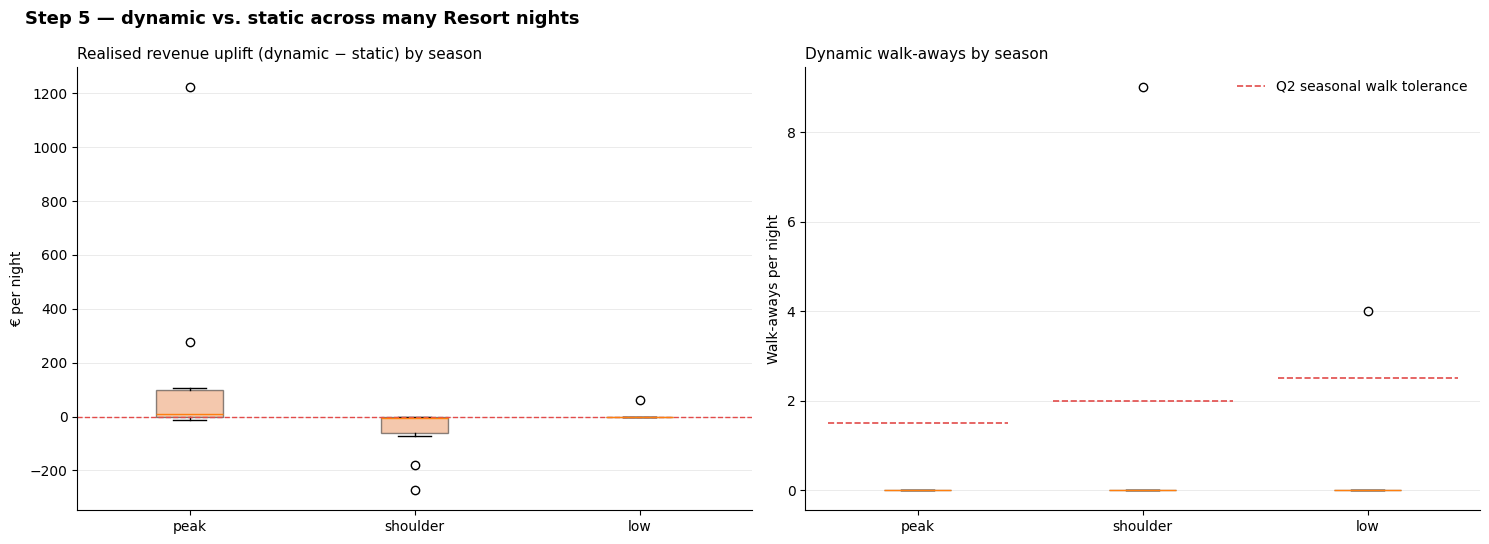

In [42]:
def sample_stay_nights(hotel, n_per_season=10, seed=7):
    rng = np.random.default_rng(seed)
    nights = []
    grid = pd.date_range("2016-01-01", "2017-08-26")
    for sea in ["peak", "shoulder", "low"]:
        months = season_months[hotel][sea]
        pool = [d for d in grid if d.month in months]
        if pool:
            nights += list(rng.choice(pool, size=min(n_per_season, len(pool)), replace=False))
    return [pd.Timestamp(d) for d in nights]

results = []
for night in sample_stay_nights(hotel_str):
    s = extract_strip(bookings, night, hotel_str, room_type)
    if len(s) < 0.6 * cap:                 # skip only genuinely thin nights
        continue
    s["p_cancel"] = pipe.predict_proba(s[feat_cols])[:, 1]
    sea = season_of(night, hotel_str)
    protect, fc, buf = q3_params_for(sea, hotel_str)

    acc_s, _ = run_static(s, cap, protect, fc, buffer=buf)
    acc_d, _ = run_dynamic(s, cap, fc, demand_model, protect, sea, night, ob_ceiling=cap + buf)

    results.append({
        "night": night, "season": sea,
        **{f"static_{k}":  v for k, v in realised_outcome(acc_s, cap).items()},
        **{f"dynamic_{k}": v for k, v in realised_outcome(acc_d, cap).items()},
    })

res = pd.DataFrame(results)
res["rev_delta"] = res["dynamic_realised_revenue"] - res["static_realised_revenue"]
def walk_tol_for(sea):                                     # Q2 seasonal tolerance (rooms)
    return walk_count_tolerance_frac[hotel_str] * cap * season_tol_scale[sea]

res["walk_tol"] = res["season"].map(walk_tol_for)
res["over_tol"] = res["dynamic_walk_aways"] > res["walk_tol"]

summary = res.groupby("season").agg(
    nights=("rev_delta", "size"),
    mean_rev_delta=("rev_delta", "mean"),
    max_rev_delta=("rev_delta", "max"),
    win_rate=("rev_delta", lambda x: (x > 0).mean()),
    static_walk_mean=("static_walk_aways", "mean"),
    dyn_walk_mean=("dynamic_walk_aways", "mean"),
    static_walk_max=("static_walk_aways", "max"),
    dyn_walk_max=("dynamic_walk_aways", "max"),
    static_over_tol=("static_walk_aways", lambda s: (s > res.loc[s.index, "walk_tol"]).mean()),
    dyn_over_tol=("over_tol", "mean"),
).round(2)
display(summary)


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
order = ["peak", "shoulder", "low"]
data  = [res.loc[res.season == s, "rev_delta"] for s in order]
bp = axes[0].boxplot(data, tick_labels=order, patch_artist=True)
for patch in bp["boxes"]:
    patch.set(facecolor="#E8864A", alpha=0.45)
axes[0].axhline(0, color="#E24B4A", linewidth=1.0, linestyle="--")
axes[0].set_title("Realised revenue uplift (dynamic − static) by season", loc="left", fontsize=11)
axes[0].set_ylabel("€ per night")
axes[0].yaxis.grid(True, linewidth=0.4, color="gainsboro"); axes[0].set_axisbelow(True)
axes[0].spines[["top", "right"]].set_visible(False)

dw = [res.loc[res.season == s, "dynamic_walk_aways"] for s in order]
bp2 = axes[1].boxplot(dw, tick_labels=order, patch_artist=True)
for patch in bp2["boxes"]:
    patch.set(facecolor="#378ADD", alpha=0.45)
for i, s in enumerate(order, start=1):                     # one tolerance mark per season box
    tol_s = walk_tol_for(s)
    axes[1].hlines(tol_s, i - 0.4, i + 0.4, color="#E24B4A",
                   linewidth=1.2, linestyle="--",
                   label="Q2 seasonal walk tolerance" if i == 1 else None)
axes[1].set_title("Dynamic walk-aways by season", loc="left", fontsize=11)
axes[1].set_ylabel("Walk-aways per night")
axes[1].yaxis.grid(True, linewidth=0.4, color="gainsboro"); axes[1].set_axisbelow(True)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False)

fig.suptitle("Step 5 — dynamic vs. static across many Resort nights",
             x=0.02, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

Against a static baseline that overbooks by the seasonal buffer, the dynamic policy concentrates its gains entirely in peak season. In peak it adds roughly €168 of realised revenue per night on average, reaching about €1,220 on the highest-pressure nights, at no risk cost. Walk-aways are zero for both policies across all ten peak nights. The average is driven by a handful of heavily contested nights rather than a uniform edge, so the policy wins on five of the ten and ties the rest, but every win is free of walk-aways.

Shoulder and low season tell the opposite story. In shoulder the dynamic policy never beats the static rule on revenue, and it does not buy lower walk risk in exchange. Both policies breach the walk tolerance on the same single night, with comparable counts. In low season the revenue difference is negligible and the dynamic policy actually walks slightly more guests than the static rule. With buffer, the dynamic model earns its keep only where pricing power and demand pressure are highest.

### Communication: the Booking-Pressure trajectory

The policy is transparent because Booking Pressure reduces the decision to one interpretable number. Plotting $BP_{t}$ across the strip against the BP = 1 line shows when the policy shifts from selling to protecting. 

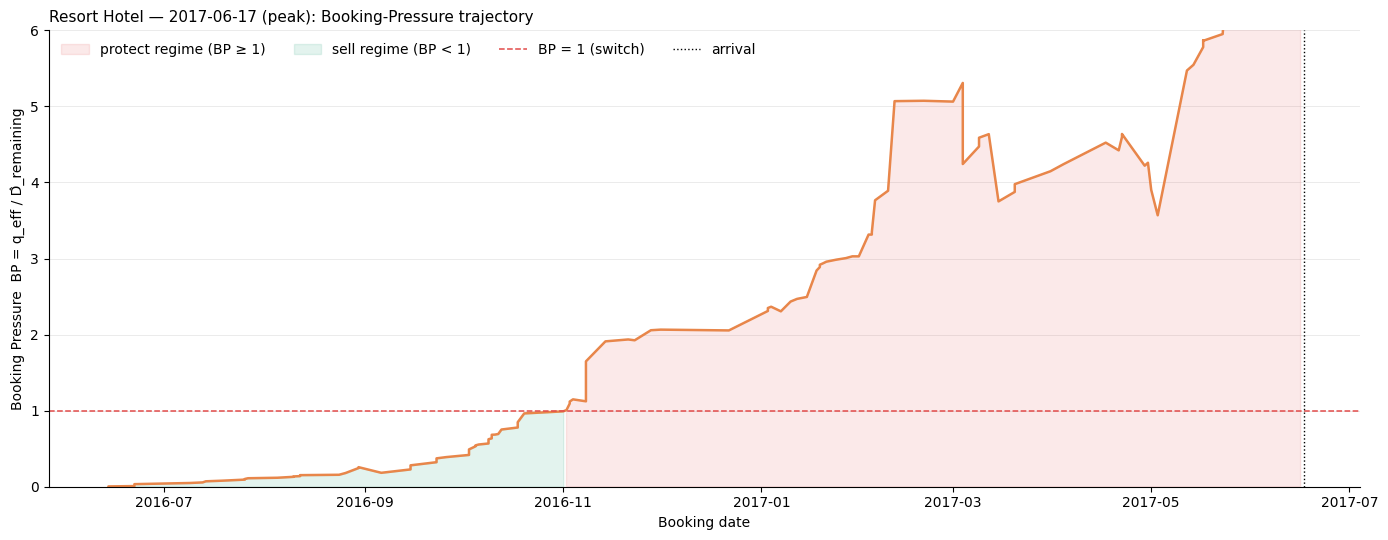

In [43]:
tr = bp_trace.reset_index(drop=True)
x  = pd.to_datetime(tr["booking_date"])          # echtes Datum statt Index

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.fill_between(x, 0, tr["BP"], where=tr["BP"] >= 1, color="#E24B4A", alpha=0.12,
                label="protect regime (BP ≥ 1)")
ax.fill_between(x, 0, tr["BP"], where=tr["BP"] < 1, color="#1D9E75", alpha=0.12,
                label="sell regime (BP < 1)")
ax.plot(x, tr["BP"], color="#E8864A", linewidth=1.8)
ax.axhline(1, color="#E24B4A", linewidth=1.1, linestyle="--", label="BP = 1 (switch)")
ax.axvline(stay_date, color="black", linewidth=1.0, linestyle=":", label="arrival")  # Anreise markieren
ax.set_ylim(0, min(tr["BP"].max() * 1.05, 6))
ax.set_xlabel("Booking date")
ax.set_ylabel("Booking Pressure  BP = q_eff / D̂_remaining")
ax.set_title(f"{hotel_str} — {stay_date.date()} ({season_label}): "
             "Booking-Pressure trajectory", loc="left", fontsize=11)
ax.yaxis.grid(True, linewidth=0.4, color="gainsboro"); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=4)
plt.tight_layout(); plt.show()

### Verdict and Recommendation 

The dynamic policy meets the three relevant criteria, but the comparison sharpens where it is actually worth deploying. It is transparent because every decision reduces to one number, Booking Pressure, whose meaning a non-technical reader can grasp and whose switch point is visible on the trajectory above. On this peak night the policy moves into the protect regime months before arrival, far earlier than a static fixed protection level would bind, which is the source of its advantage.

It is robust in the narrow sense that matters. In peak season the dynamic policy still adds revenue, around €168 per night on average and up to roughly €1,220 on the most contested nights, without adding a single walk-away. Outside peak it no longer earns its complexity. In shoulder season it does not beat the static rule on any night and does not lower walk risk, and in low season it is revenue-neutral while walking marginally more guests. 

The recommendation is therefore tight. Deploy the dynamic policy in peak season only, where demand pressure is high enough that adapting intake to expected shows captures real revenue at no walk-away cost. In shoulder and low season, keep the static seasonal rule from Q3. A well-sized fixed buffer is already as good or better, and a simpler rule is easier to operate and monitor. This mirrors the Q3 finding from the operations side. Seasonality is the axis that decides where live adaptation is worth its added complexity, and the fair baseline shows that window is narrower than the headline numbers first suggested.

## Reflection & methodology

The four questions form one evolving argument. A single advance-sale number per hotel (Q1), a single overbooking buffer per hotel (Q2), the same two numbers re-cut by season (Q3), and finally a rule that re-decides at every request (Q4). Three methodological commitments hold the chain together. 

First, everything price-related is calibrated on realised stays only and on the canonical A/BB/2 tuple, so timing effects are never contaminated by cancellations or by composition drift. Second, the cancellation model is used as a calibrated probability rather than a classifier. The quantity expected_show = 1 − p_cancel is what turns "rooms sold" into "rooms expected", and it is what makes overbooking a controlled risk. Third, every layer is a continuous refinement of the one before it. Q4's base_protect is the Q3 protection level and Q4's overbooking ceiling is the Q2 buffer, so the dynamic policy degrades to the static rule when the live signal is uninformative. One scope decision follows directly from this chain. Because Q3 showed the City Hotel's ADR profile to be almost flat, we apply the dynamic policy to the Resort only, where seasonality and pricing power are strong enough for live adaptation to earn back its complexity.

### 1. The single most important assumption

The key factor is that the cancellation model's calibration generalises from the historical book to the live high-season book. The entire Q4 mechanism is expected-show accounting. Booking Pressure's numerator, the implicit overbooking and the ceiling that bounds it all assume that a booking the model scores at 30 % cancellation risk truly shows up about 70 % of the time. We did not have to speculate about what happens when this breaks, because the robustness sweep showed it directly. In peak, where the model is well calibrated, walk-aways stayed inside the tolerance on every night in the sample. Off peak the calibration is noisier, and the policy breached the walk tolerance on roughly one night in ten, with a single shoulder night reaching nine walk-aways. If the assumption broke at scale, for example because the high season draws a different channel or deposit mix than the training years, the failure would not be a quiet loss of revenue but a visible spike in walk-aways. Real guests turned away, relocation costs, and brand damage, which for the Resort is precisely the outcome Q2 was most conservative about.

A second factor is the stated 80-room capacity, since the dataset has no capacity column. It scales every buffer and protection level, so a wrong capacity rescales every recommendation proportionally. We checked the other free inputs directly. The Q2 sensitivity analysis recomputed the buffer across a grid of risk appetite and walk tolerance and found the chosen operating point sitting well inside a flat region, so those managerial choices move the recommendation by only a few rooms. Capacity is the one assumption that escapes that check.

A related structural assumption is the conditional independence of cancellations. The Poisson-binomial-normal walk-risk model in Q2, inherited by Q4's ceiling, treats each booking's show or no-show as independent. This is reasonable for transient demand but wrong for block or tour-operator bookings, where one decision cancels many rooms at once. Correlated cancellations differ from the normal approximation, so the true probability of a large walk event is understated. 

### 2. What we simplified

Several abstractions were acceptable for a back-test.

The first is how cancellations are released over time. Our policy anticipates cancellations aggregated through q_eff, but it never sees an individual cancellation happen mid-stream and free up a room. The replay runs the strip as a frozen sequence of arrivals, with is_canceled revealed only at the end, so there is no point at which a cancellation returns inventory that could be actively resold. A live system observes cancellations as they land and can re-offer the freed room, and doing that on top of a fixed buffer compounds exposure unless total commitment is controlled. Q4 sidesteps this by design rather than solving it.

The second is demand stationarity. The regressor is trained on 2015–2017 curves and assumes the shape of the booking curve, how high-fare demand arrives as a function of days-to-arrival. Events, competitor price moves, holiday-calendar shifts, or a shock would all move that curve, and the model has no way to detect or adapt to such drift within a season.

The third is composition drift. Both the calibrated p_cancel and the season-median fare_cut assume the future book resembles the historical hotel-season mix. A shift would degrade the calibration and misplace the high/low fare split at the same time.

The fourth is scope. We fixed a single room type, treated each night as an independent experiment, and worked with  two fare classes with a fixed threshold.

The last is the difference between no-shows and cancellations. We treat is_canceled as the only non-arrival signal, but a day-of-arrival no-show carries different risks and is not modelled separately.

### 3. What we would do with one more week

First, we would improve both models. The cancellation model off-peak and the demand model to better handle outliers. The cancellation model is well calibrated in peak season but noisier in shoulder and low season, which is directly where the unexpected walk-aways happened. Refining the training data or features for these quieter periods would be our top priority to stabilize the policy's risk profile.

Second, we would let the demand forecast express uncertainty. Right now the regressor predicts a single number for remaining high-fare demand, but it is off by around 13 requests on average. A model that predicts a range instead of a point would let the policy protect against the risk of a late surge, not just the expected case. This is probably the change that would help most off peak.

Third, we would also make the occupancy counting consistent across all four questions. In Q1 to Q3 a booking is attached to its arrival date, but a multi-night stay actually occupies several nights, so counting only the arrival night understates true occupancy. Q4 already handles this by checking which nights each booking spans, and we would apply the same span-based counting throughout so that capacity is measured the same way everywhere.

### Final comment

All in all, these factors represent opportunities for improvement rather than critical weaknesses. The approach already performs well in peak season, where it matters most. Even with a single room type, a frozen booking strip, and a cancellation model calibrated only off the historical book, the dynamic policy beat a fair, overbooking static baseline in peak season at no walk-away cost, while off peak a well-sized static buffer proved just as good and the static rules in Q1–Q3 produced sensible, defensible numbers in their own right. The simplifications we listed do not fundamentally undermine the central result. They mark where the next gains are, not where the current ones break. The maturity-curve progression we set out to demonstrate, from a single static number to a rule that re-decides at every request, holds up end to end.